# About the dataset

Diabetes is a serious chronic disease in which individuals lose the ability to effectively regulate levels of glucose in the blood, and can lead to reduced quality of life and life expectancy. After different foods are broken down into sugars during digestion, the sugars are then released into the bloodstream. This signals the pancreas to release insulin. Insulin helps enable cells within the body to use those sugars in the bloodstream for energy. Diabetes is generally characterized by either the body not making enough insulin or being unable to use the insulin that is made as effectively as needed.

Complications like heart disease, vision loss, lower-limb amputation, and kidney disease are associated with chronically high levels of sugar remaining in the bloodstream for those with diabetes. While there is no cure for diabetes, strategies like losing weight, eating healthily, being active, and receiving medical treatments can mitigate the harms of this disease in many patients. Early diagnosis can lead to lifestyle changes and more effective treatment, making predictive models for diabetes risk important tools for public and public health officials.

* The data contains 70692 rows and 22 features

-----------------------------------------------------------------------------------------

GenHlth:
The metadatt indicates that patients were asked to rate their overall health status on a 1-5 scale, where:

1 = Excellent
2 = very good
3 = good
4 = fair
5 = poor

-----------------------------------------------------------------------------------------

BMI:
For adults 20 years old and older, BMI is interpreted using standard weight status categories. These categories are the same for men and women of all body types and ages.

If your BMI is less than 18.5, it falls within the underweight range.
If your BMI is 18.5 to 24.9, it falls within the Healthy Weight range.
If your BMI is 25.0 to 29.9, it falls within the overweight range.
If your BMI is 30.0 or higher, it falls within the obese range.

-----------------------------------------------------------------------------------------

Age:
MetaData explains that is patient age classification with 5 year increments, where:

1 = 18-24 years old
2 = 25-29 years old
3 = 30-34 years old
4 = 35-39 years old
5 = 40-44 years old
6 = 45-49 years old
7 = 50-54 years old
8 = 55-59 years old
9 = 60-64 years old
10 = 65-69 years old
11 = 70-74 years old
12 = 75-79 years old
13 = 80 years and older

-----------------------------------------------------------------------------------------

Income:
MetaData explains that is patient Annual household income in dollar, where:

1 = <10,000
2 = 10,000–15,000
3 = 15,000–20,000
4 = 20,000–25,000
5 = 25,000–35,000
6 = 35,000–50,000
7 = 50,001–75,000
8 = >75,000

-----------------------------------------------------------------------------------------

Education:
What is the highest grade or year of school you completed?

1 = Never attended school or only kindergarten
2 = Grades 1 through 8 (Elementary)
3 = Grades 9 through 11 (Some high school)
4 = Grade 12 or GED (High school graduate)
5 = College 1 year to 3 years (Some college or technical school)
6 = College 4 years or more (College graduate)

-----------------------------------------------------------------------------------------

# Data exploration 

In [1]:
#used libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk
from tkinter import ttk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from ydata_profiling import ProfileReport
import sweetviz as sv

In [2]:
def load_data(csv_file, target_column='Diabetes_binary'):
    """Loads the data, renames the target, and splits into train/test."""
    df = pd.read_csv(csv_file)
    df.rename(columns={target_column: 'target'}, inplace=True)
    X = df.drop(columns=['target'])
    y = df['target']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test, df


In [3]:
X_train, X_test, y_train, y_test,df = load_data(r"C:\Users\dell\Downloads\diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

In [4]:
df.head()

,target,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [5]:
#display random 5 records
df.sample(5).T

,13129,40652,36189,14498,25198
target,0.0,1.0,1.0,0.0,0.0
HighBP,0.0,1.0,1.0,0.0,1.0
HighChol,0.0,0.0,0.0,0.0,1.0
CholCheck,1.0,1.0,1.0,1.0,1.0
BMI,22.0,20.0,44.0,33.0,42.0
Smoker,1.0,1.0,0.0,1.0,1.0
Stroke,1.0,0.0,0.0,0.0,0.0
HeartDiseaseorAttack,0.0,1.0,0.0,0.0,0.0
PhysActivity,1.0,0.0,1.0,1.0,0.0
Fruits,0.0,1.0,0.0,1.0,0.0


In [6]:
# displaying some statistical summary of numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
target,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


In [7]:
# displaying information about  the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   target                70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

In [8]:
# displaying each column has how many unique values
df.nunique()

target                   2
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     80
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64

In [9]:
# displaying the data shape (rows, columns)
rows , col =  df.shape
print(f"Number of Rows : {rows} \nNumber of Columns : {col}")

Number of Rows : 70692 
Number of Columns : 22


In [10]:
# number of null values in each column
df.isna().sum()

target                  0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [11]:
# displaying number of duplicated rows
df.duplicated().sum()

1635

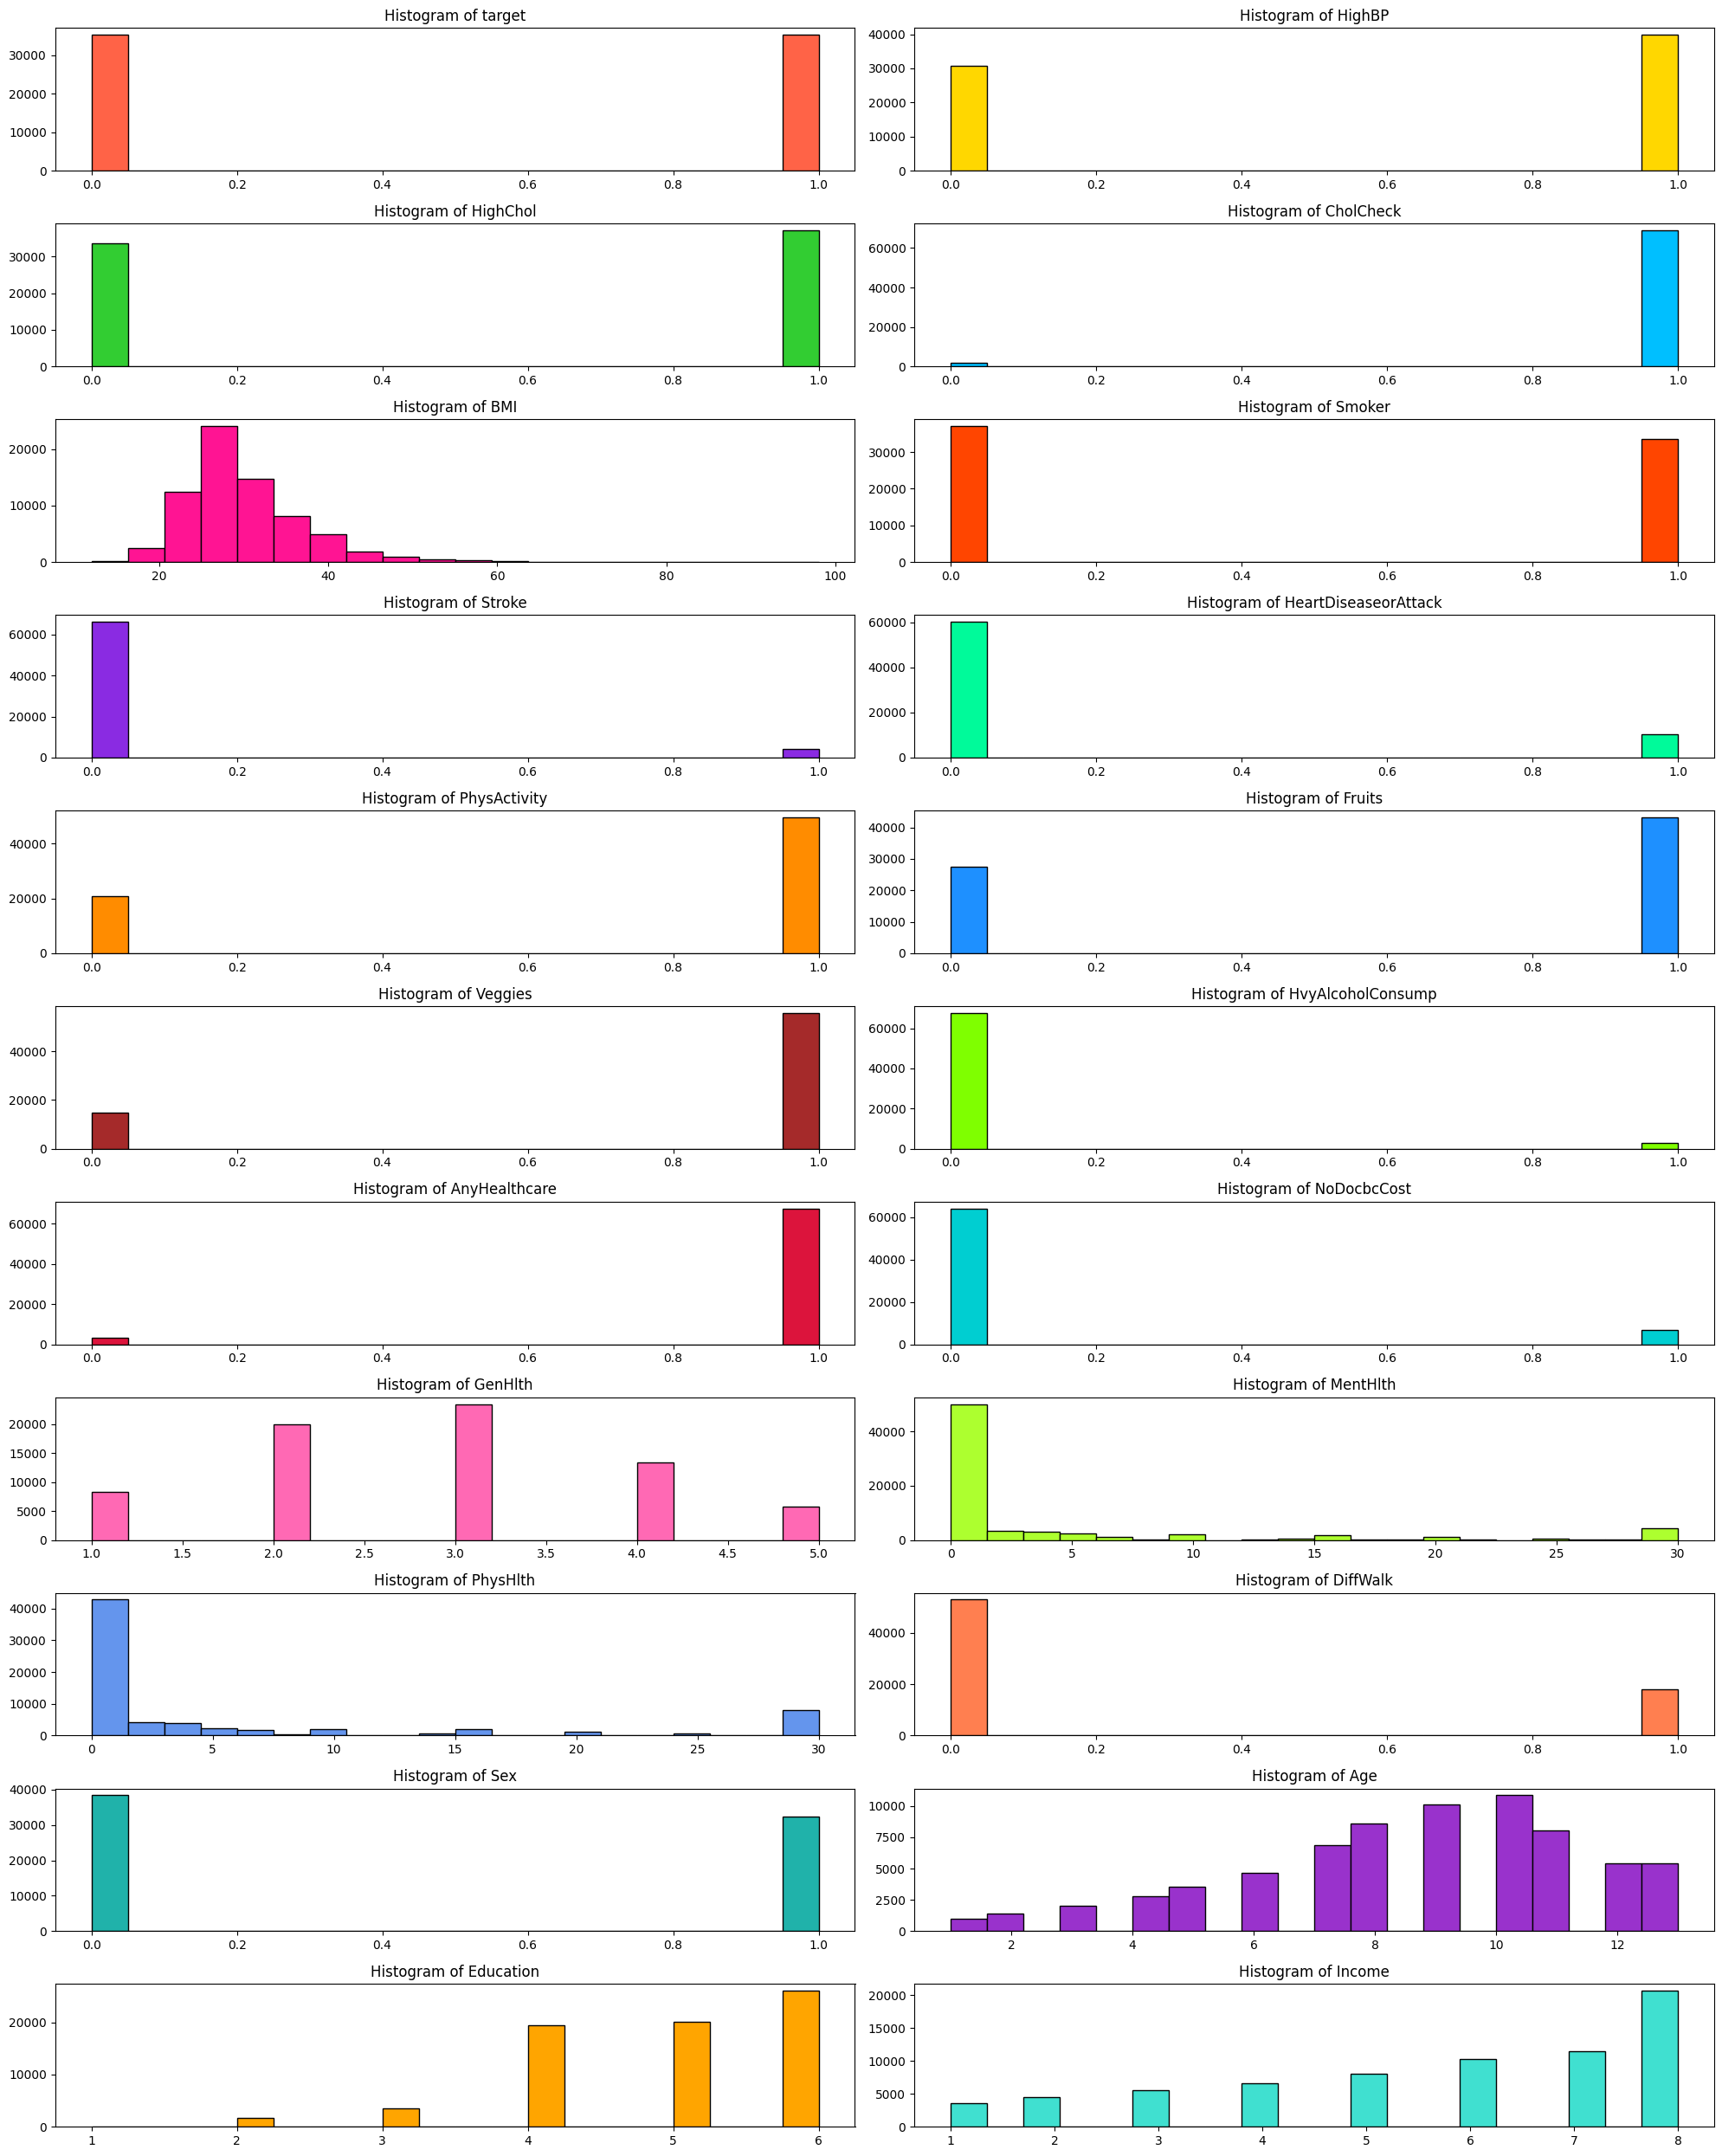

In [12]:
#plotting the distribution of each numer column
numeric_columns =  df.columns
colors = [
    '#FF6347',  # Tomato
    '#FFD700',  # Gold
    '#32CD32',  # LimeGreen
    '#00BFFF',  # DeepSkyBlue
    '#FF1493',  # DeepPink
    '#FF4500',  # OrangeRed
    '#8A2BE2',  # BlueViolet
    '#00FA9A',  # MediumSpringGreen
    '#FF8C00',  # DarkOrange
    '#1E90FF',  # DodgerBlue
    '#A52A2A',  # Brown
    '#7FFF00',  # Chartreuse
    '#DC143C',  # Crimson
    '#00CED1',  # DarkTurquoise
    '#FF69B4',  # HotPink
    '#ADFF2F',  # GreenYellow
    '#6495ED',  # CornflowerBlue
    '#FF7F50',  # Coral
    '#20B2AA',  # LightSeaGreen
    '#9932CC',  # DarkOrchid
    '#FFA500',  # Orange
    '#40E0D0'   # Turquoise
]
fig, axes = plt.subplots(nrows=11, ncols=2, figsize=(20,25))  
axes = axes.flatten()  
#iterate through each numeric column
for i,column in enumerate(numeric_columns):
    df[column].hist(bins=20,color=colors[i],edgecolor='black',ax=axes[i])
    axes[i].set_title(f'Histogram of {column}')
    axes[i].grid(False)
plt.subplots_adjust(hspace=0.5)
plt.tight_layout()
plt.show()

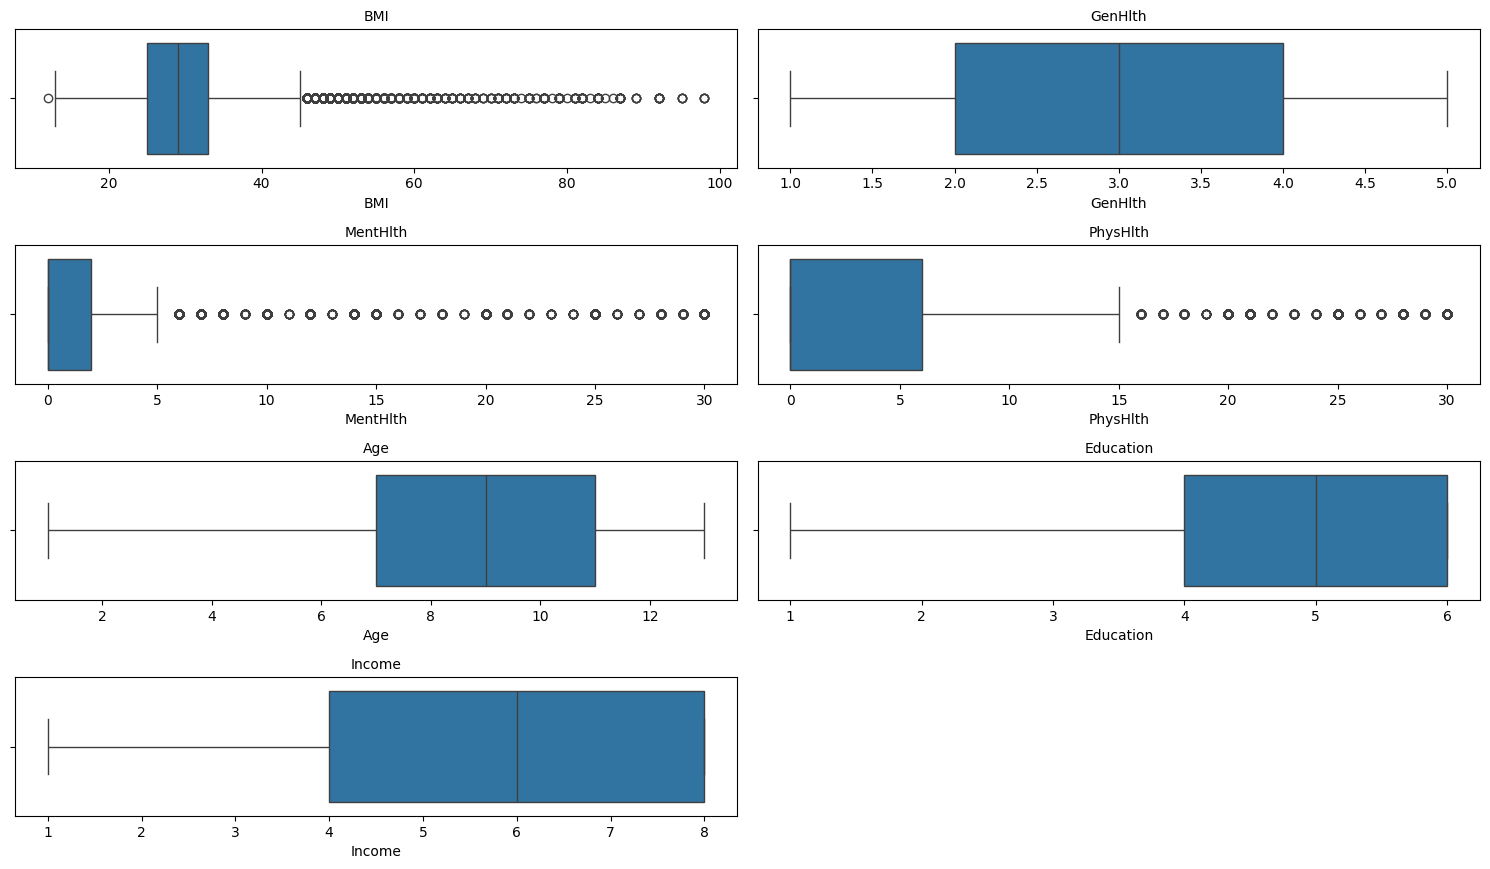

In [13]:
plt.figure(figsize=(15, 17))

c_cols = ['BMI','GenHlth','MentHlth', 'PhysHlth','Age', 'Education','Income']

for i, col in enumerate(c_cols):
    plt.subplot(8, 2, i + 1)
    sns.boxplot(x=col, data=df)
    plt.title(col, fontsize=10)  
plt.tight_layout()
plt.show()


In [14]:
df['target'].value_counts()

target
0.0    35346
1.0    35346
Name: count, dtype: int64

* All the columns are numeric
* The dataset contains 22 features and 70692 rows
* No null values
* There are 1635 duplicates
* The dataset is balanced

# Data preprocessing

In [21]:
def preprocess_data(df,X_train, X_test,y_train,y_test):
    """Scales numerical features and removes duplicates."""

    #drop duplicates
    df = df.drop_duplicates()
    X_train.drop_duplicates(inplace=True)
    X_test.drop_duplicates(inplace=True)
    y_train = y_train[X_train.index]  
    y_test = y_test[X_test.index]

    numerical_features = X_train.columns  
    numerical_pipeline = Pipeline([('scaler', StandardScaler())])
    preprocessor = ColumnTransformer([('numerical', numerical_pipeline, numerical_features)],
                                      remainder='passthrough') #
    return preprocessor, X_train, X_test, y_train, y_test, df
# passthrough : "Keep all the columns that are not mentioned in the transformer as they are (untransformed), and include them in the final output."

In [29]:
preprocessor, X_train, X_test, y_train, y_test,df = preprocess_data(df,X_train, X_test,y_train,y_test)


In [19]:
df.shape

(69057, 22)

In [20]:
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('numerical',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object'))])

# Exploratory Data Analysis

## Distribution of target variable

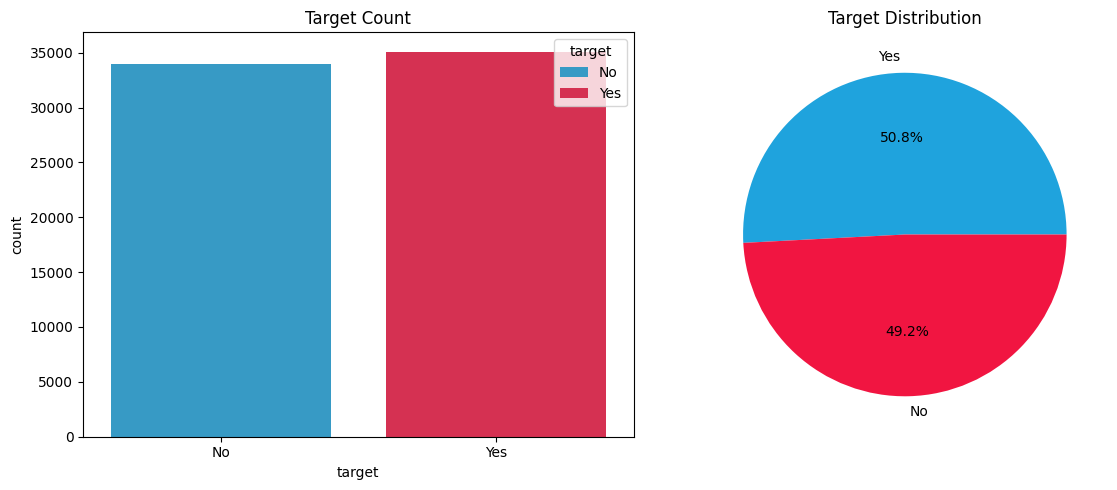

In [27]:
#plotting both count and distribution percentage for our target
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='target', data=df,hue=df['target'].map({0: 'No', 1: 'Yes'}),palette=['#1FA3DD', '#F11541'], ax=axes[0])
axes[0].set_title('Target Count')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No', 'Yes'])

target_counts = df['target'].map({0: 'No', 1: 'Yes'}).value_counts()
labels = target_counts.index
sizes = target_counts.values
colors = ['#1FA3DD', '#F11541']

axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
axes[1].set_title('Target Distribution')

plt.tight_layout()
plt.show()

* Its very obvious that the data is balanced

## Univariat

In [37]:
for column in df.columns:
    print(f"Value counts for '{column}':")
    print(df[column].value_counts())  
    print("-" * 40)

Value counts for 'target':
target
1.0    35097
0.0    33960
Name: count, dtype: int64
----------------------------------------
Value counts for 'HighBP':
HighBP
1.0    39447
0.0    29610
Name: count, dtype: int64
----------------------------------------
Value counts for 'HighChol':
HighChol
1.0    36692
0.0    32365
Name: count, dtype: int64
----------------------------------------
Value counts for 'CholCheck':
CholCheck
1.0    67317
0.0     1740
Name: count, dtype: int64
----------------------------------------
Value counts for 'BMI':
BMI
27.0    6118
26.0    4801
28.0    4452
30.0    4282
24.0    4168
        ... 
85.0       1
83.0       1
80.0       1
78.0       1
74.0       1
Name: count, Length: 80, dtype: int64
----------------------------------------
Value counts for 'Smoker':
Smoker
0.0    35776
1.0    33281
Name: count, dtype: int64
----------------------------------------
Value counts for 'Stroke':
Stroke
0.0    64662
1.0     4395
Name: count, dtype: int64
-------------------

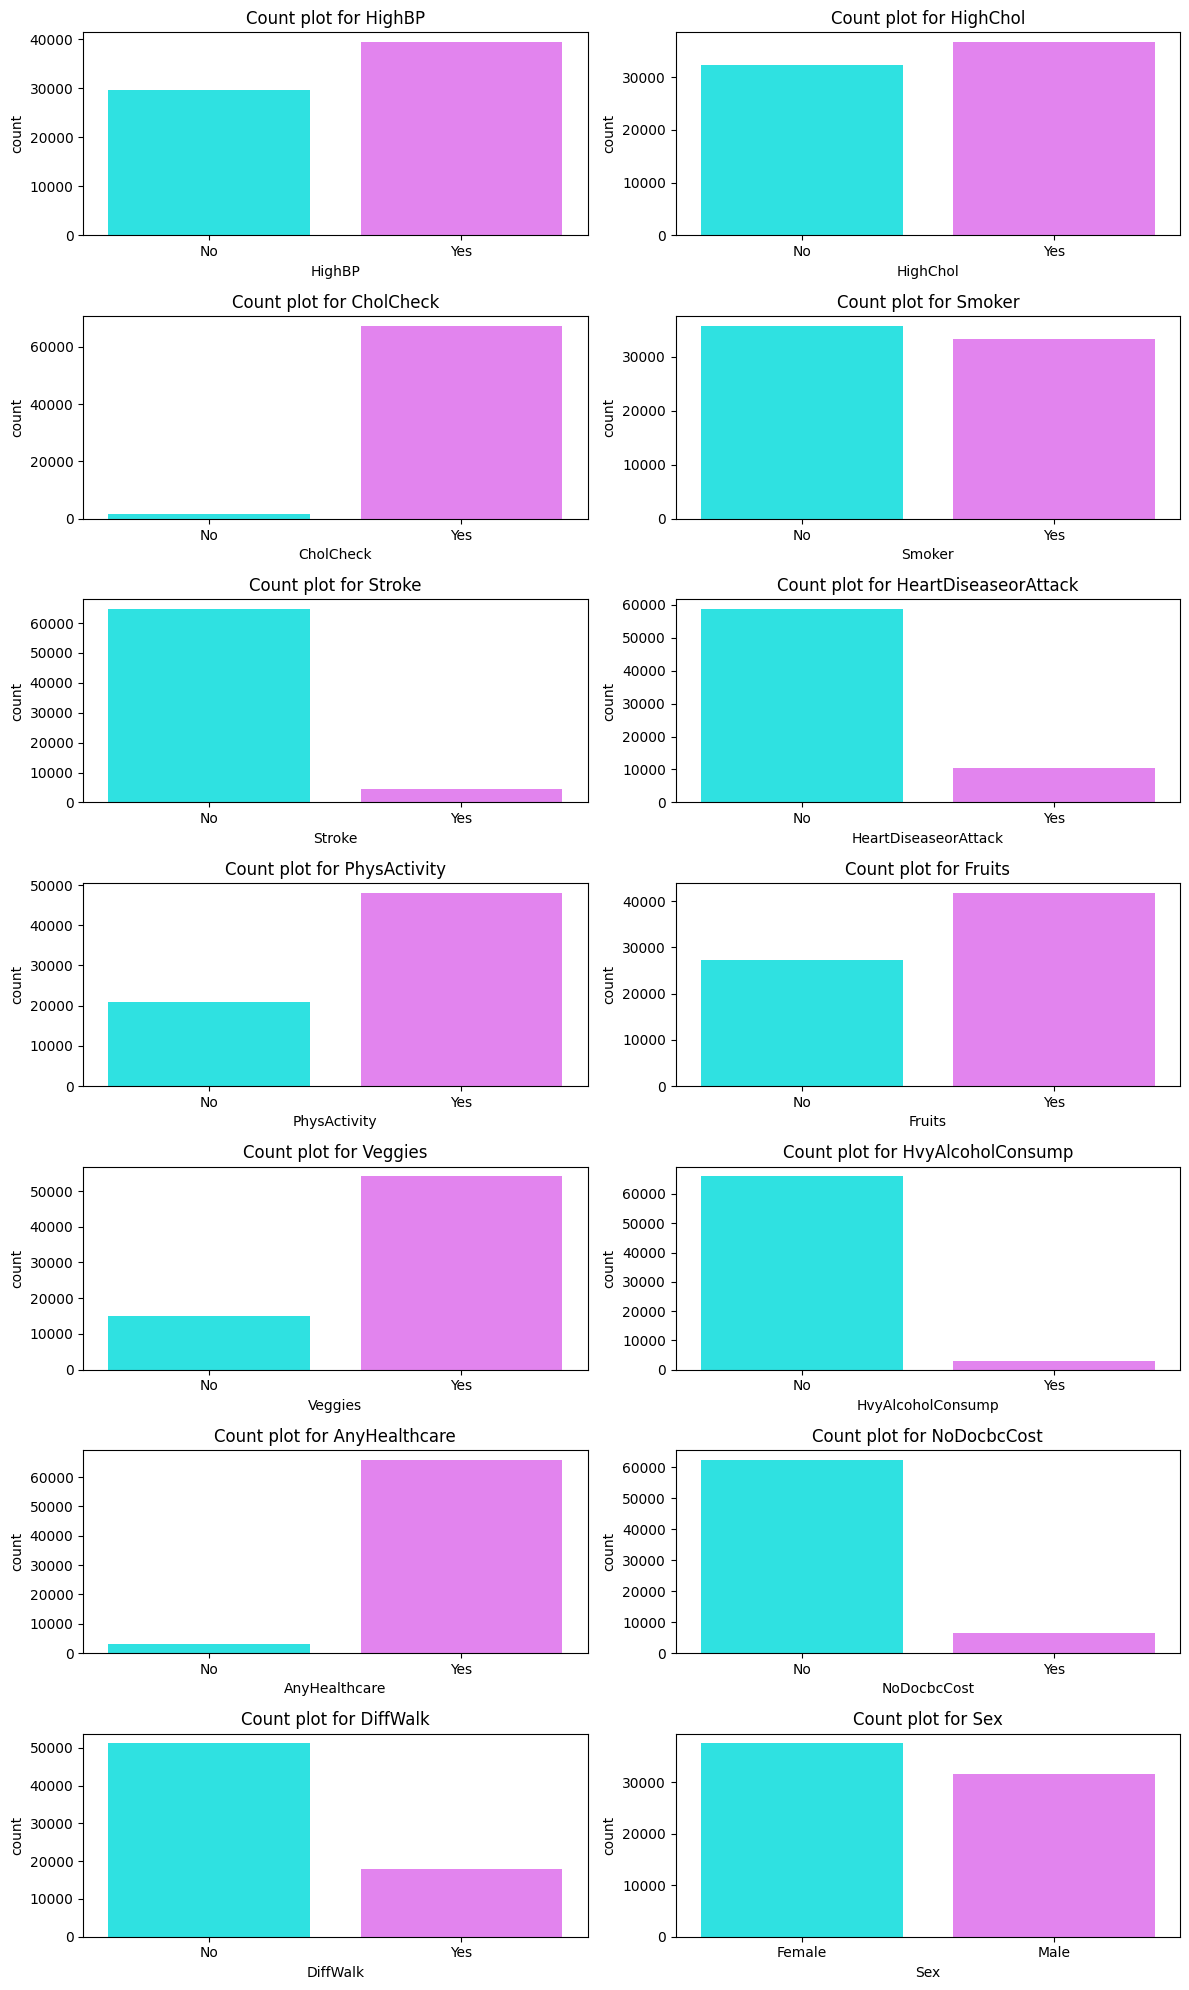

In [38]:
# plotting variables having 2 values
binary_columns = [col for col in df.columns if (df[col].nunique() == 2) and (col != 'target')]

plt.figure(figsize=(12, 20))  

for i, column in enumerate(binary_columns, 1):
    plt.subplot(7, 2, i) 
    sns.countplot(x=column, data=df, hue=column, palette=['#11FFFF', '#EF73FF'])  # Removed 'legend' here
    plt.title(f'Count plot for {column}')
    plt.legend([], [], frameon=False)  # Hides legend if you want

    if column == 'Sex':
        plt.xticks([0, 1], ['Female', 'Male'])
    else:
        plt.xticks([0, 1], ['No', 'Yes'])

plt.tight_layout()  
plt.show()


Features that are remarkable: Most of people

*  Have high blood pressure
*  High cholestrol
*  have made cholesterol check in last 5 years
*  havent been in a stroke
*  didnt have a heart attack
*  made physical activity in past 30 days
*  Consume Vegetables 1 or more times per day
*  dont consume/drink alcohol
*  Consume Fruit 1 or more times per day
*  Have any kind of health care coverage, including health insurance, prepaid plans
*  werent there a time in the past 12 months when needed to see a doctor but could not because of cost
*  have no serious difficulty walking or climbing stairs
*  are Female patients
*  Number of smokers and non smokers are almost the same

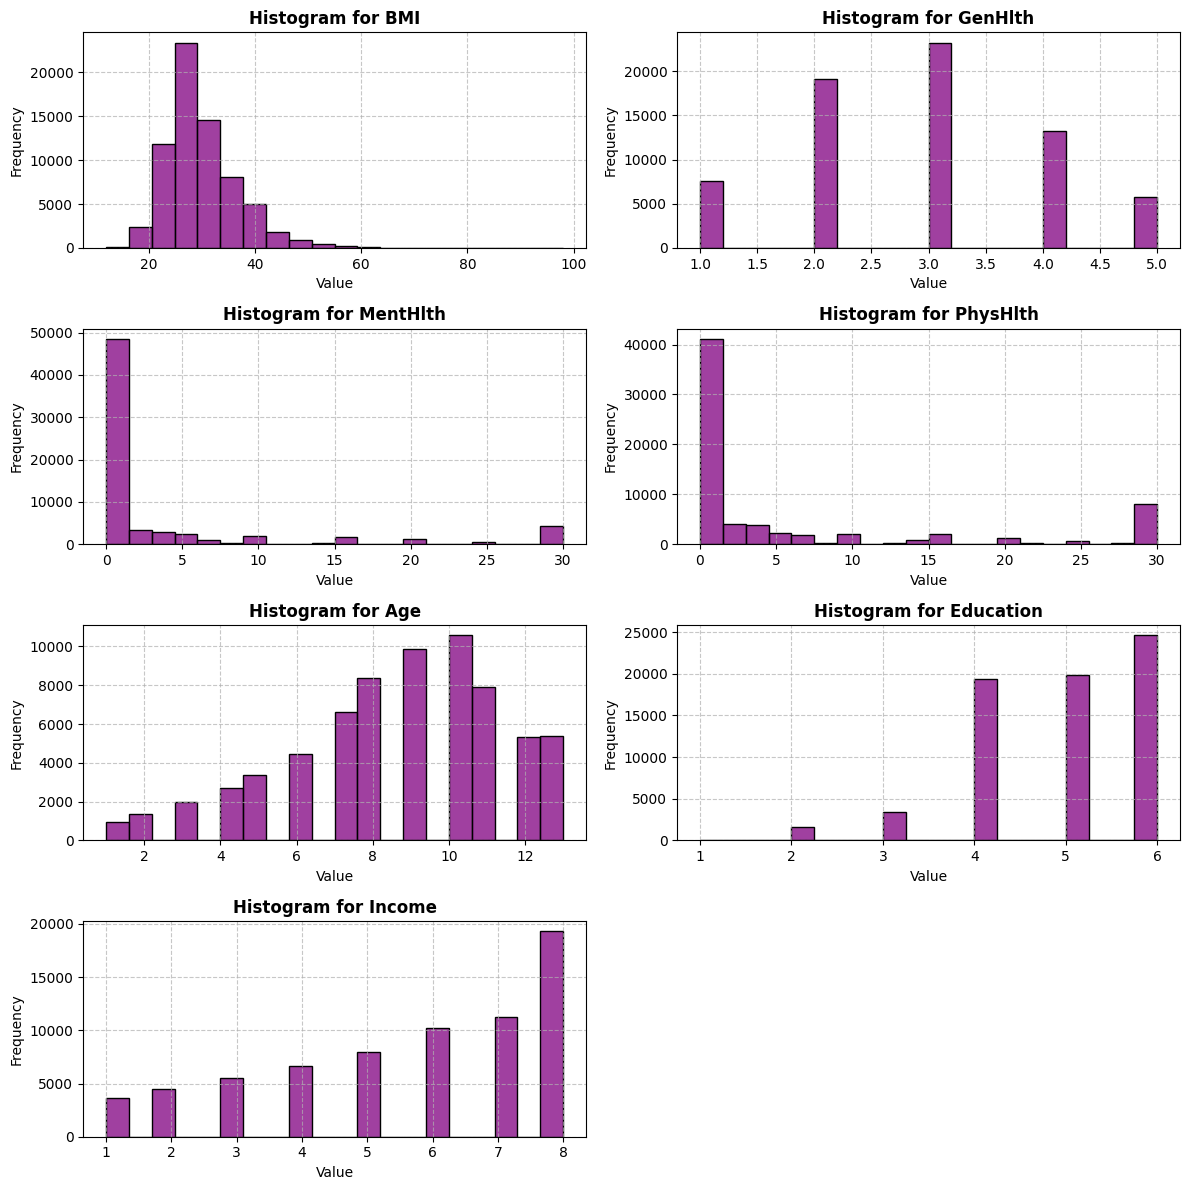

In [40]:
#plotting other variables 
c_cols = ['BMI','GenHlth','MentHlth', 'PhysHlth','Age', 'Education','Income']

plt.figure(figsize=(12, 3 * 4))  
for i, column in enumerate(c_cols, 1):
    plt.subplot(4, 2, i)  
    sns.histplot(df[column], bins=20,color='purple') 
    plt.title(f"Histogram for {column}", fontsize=12, fontweight='bold')  
    plt.xlabel('Value', fontsize=10)  
    plt.ylabel('Frequency', fontsize=10)  
    plt.grid(True, linestyle='--', alpha=0.7)  
plt.tight_layout() 
plt.show()


We can notice Most people:

* Have bmi between 20 and 45
* Their general health is good
* days of poor mental health is between 0 to 5 days
* physical illness or injury days in past 8 days
* Their age is above 50
* Their education is high
* Their income is from $35,000 and above

## Bivariate

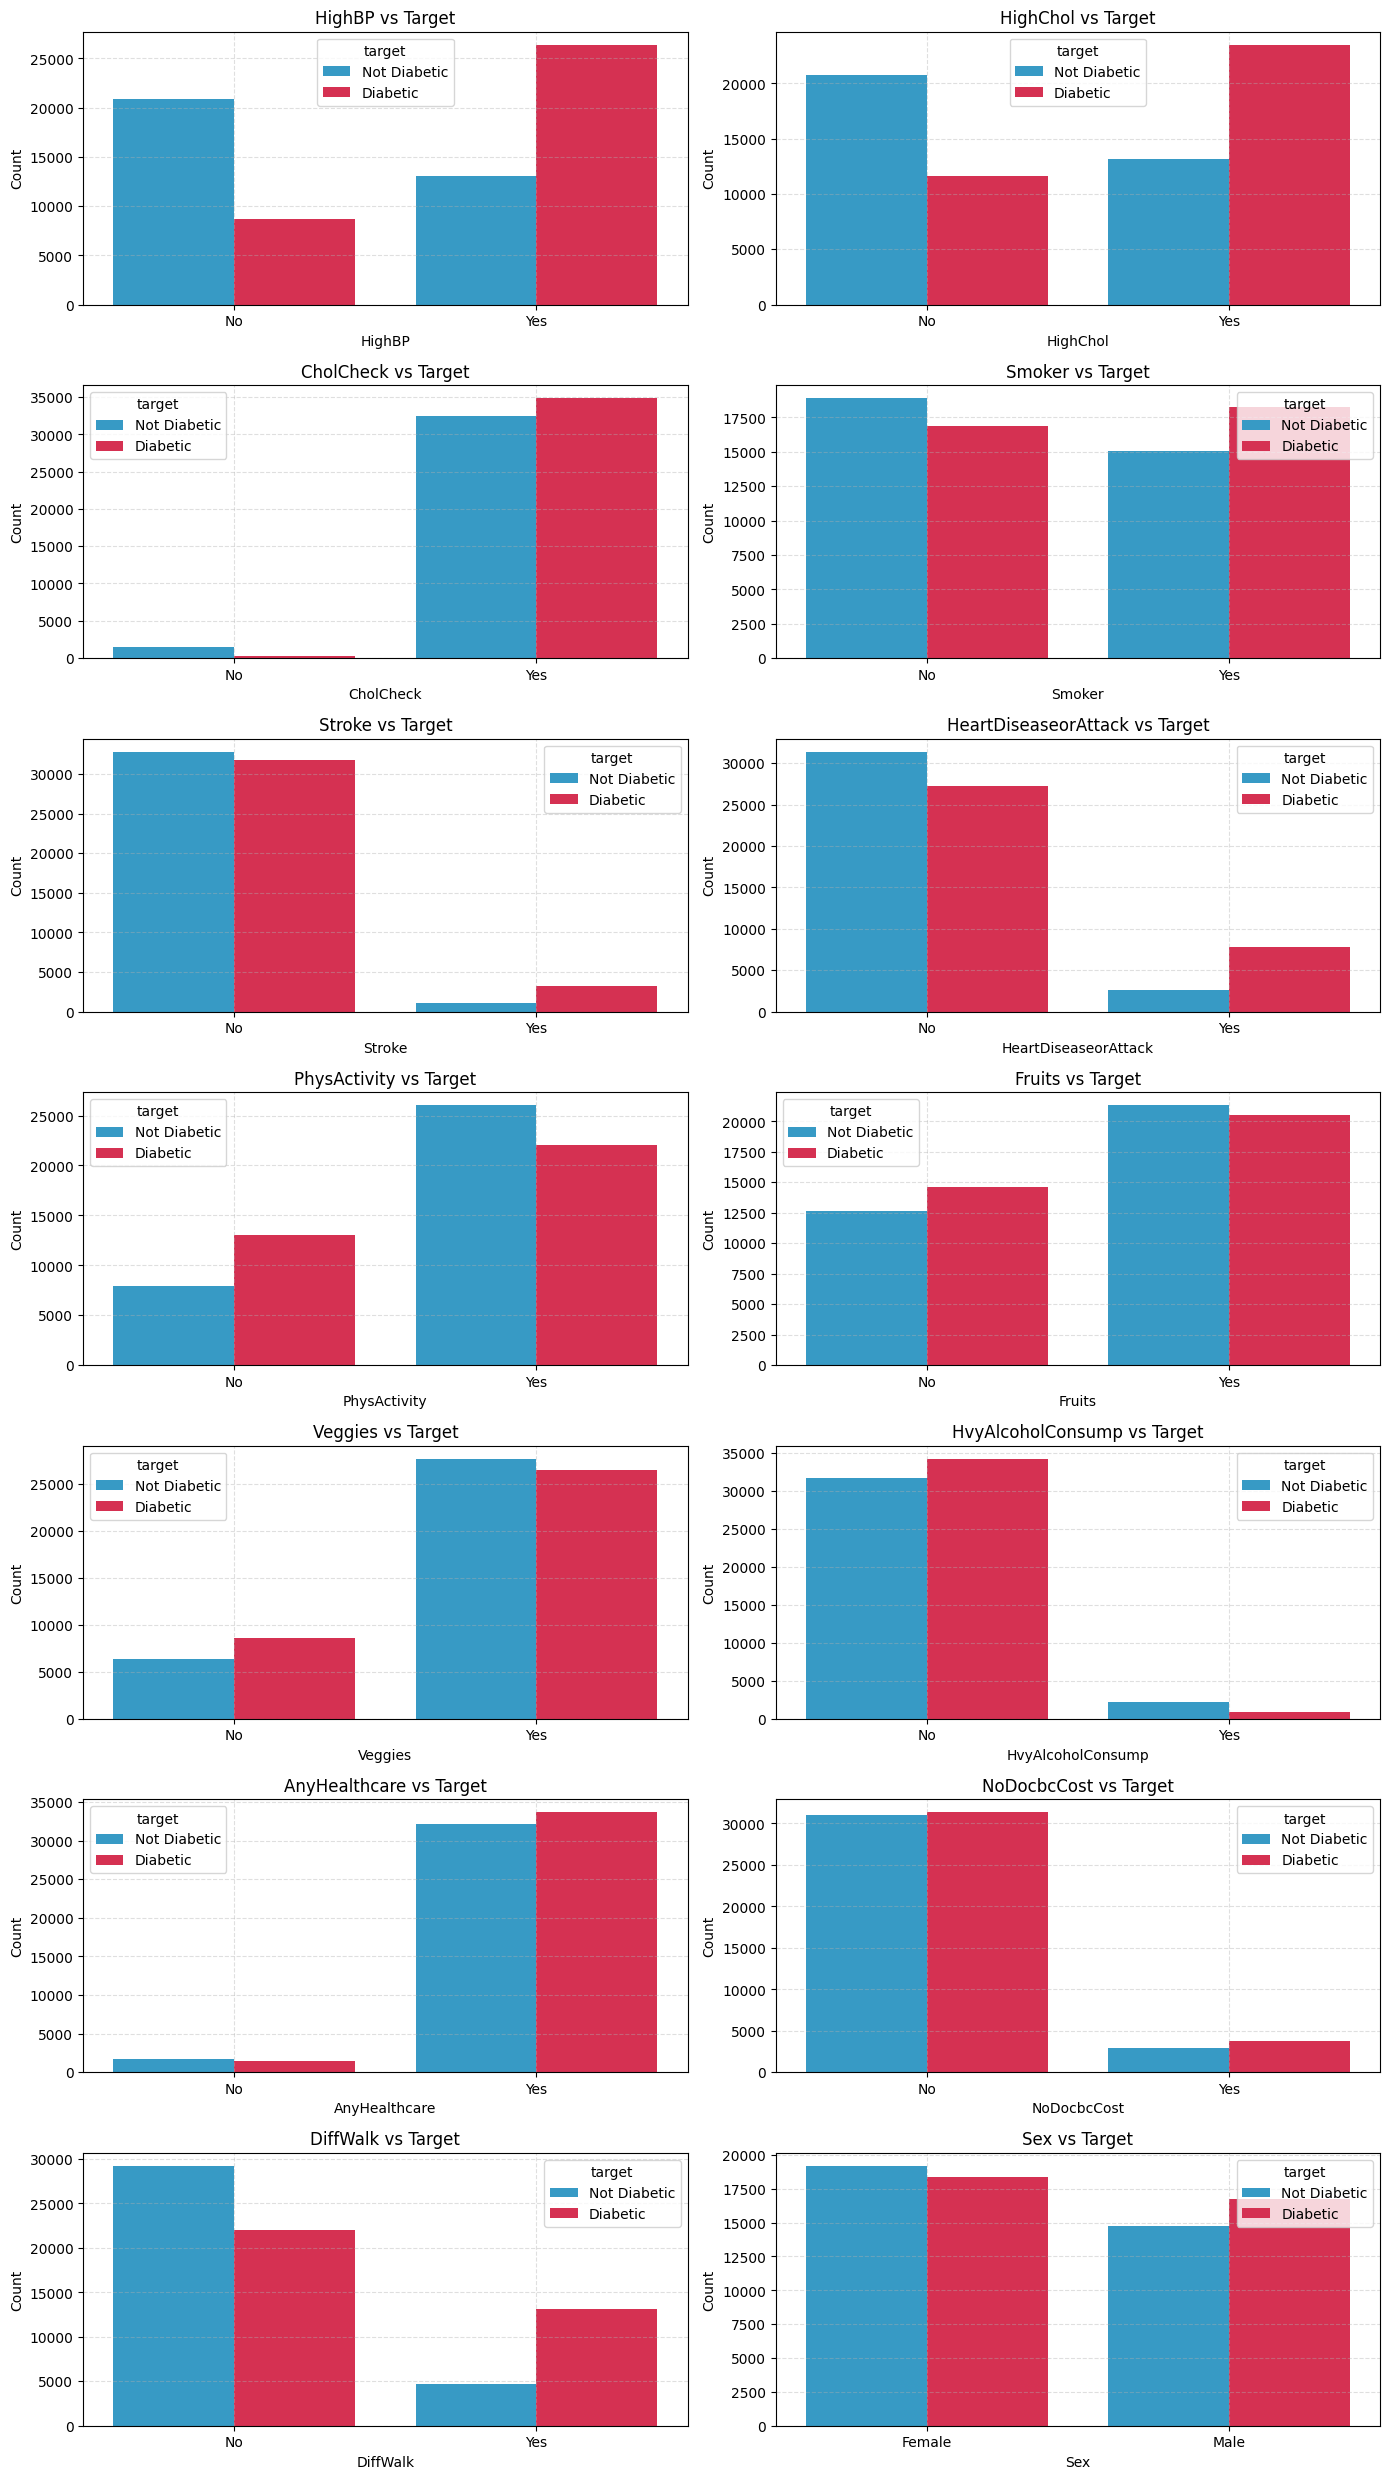

In [43]:
plt.figure(figsize=(14, 28))  
for i, col in enumerate(binary_columns, 1):
    plt.subplot(8, 2, i)
    sns.countplot(data=df, x=col, hue=df['target'].map({0: 'Not Diabetic', 1: 'Diabetic'}), palette=['#1FA3DD', '#F11541'])
    plt.title(f"{col} vs Target", fontsize=12)
    plt.xlabel(col)
    plt.ylabel("Count")
    
    if col == 'Sex':
        plt.xticks([0, 1], ['Female', 'Male'])
    else:
        plt.xticks([0, 1], ['No', 'Yes'])

    plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

We can see:
* Most diabetic patients have High blood pleasure (obvious relation)
* Most diabetic patients have High cholesterol (obvious relation)
* Most people who have made cholesterol check are Diabetic (reasonable)
* Smoking is not a good indecator
* people who had stroke are likely diabetic but in general diabetic people didnt have stroke
* people who had heart disease arelikely diabetic but in general diabetic people didnt have heart disease
* Diabetic people who make physical activites are more than who dont but in general people who make physical activity dont have diabetes
* Eating fruits doesnt mean no diabetes as diabetic people who eat fruits are more than who dont but in general people who make eat fruits dont have diabetes (but still people who dont eat fruits are diabetic)
* Also eating veggies will not prevent you from diabetes as we can see most of diabetic people eat veggies(but still people who dont eat veggies are diabetic)
* Drinking alcohol does not affect diabetes as we can see diabetic people who dont consume alcohol are more than who do consume
* Having a Health care coverage will not prevent you from diabetes
* Not Seeing a doctor is not a good indecator
* Diabetic people are likely to have diffeculty in walk than who arent but its not a correlation as most diabetic people dont have a difficulty
* Most diabetic patients are females

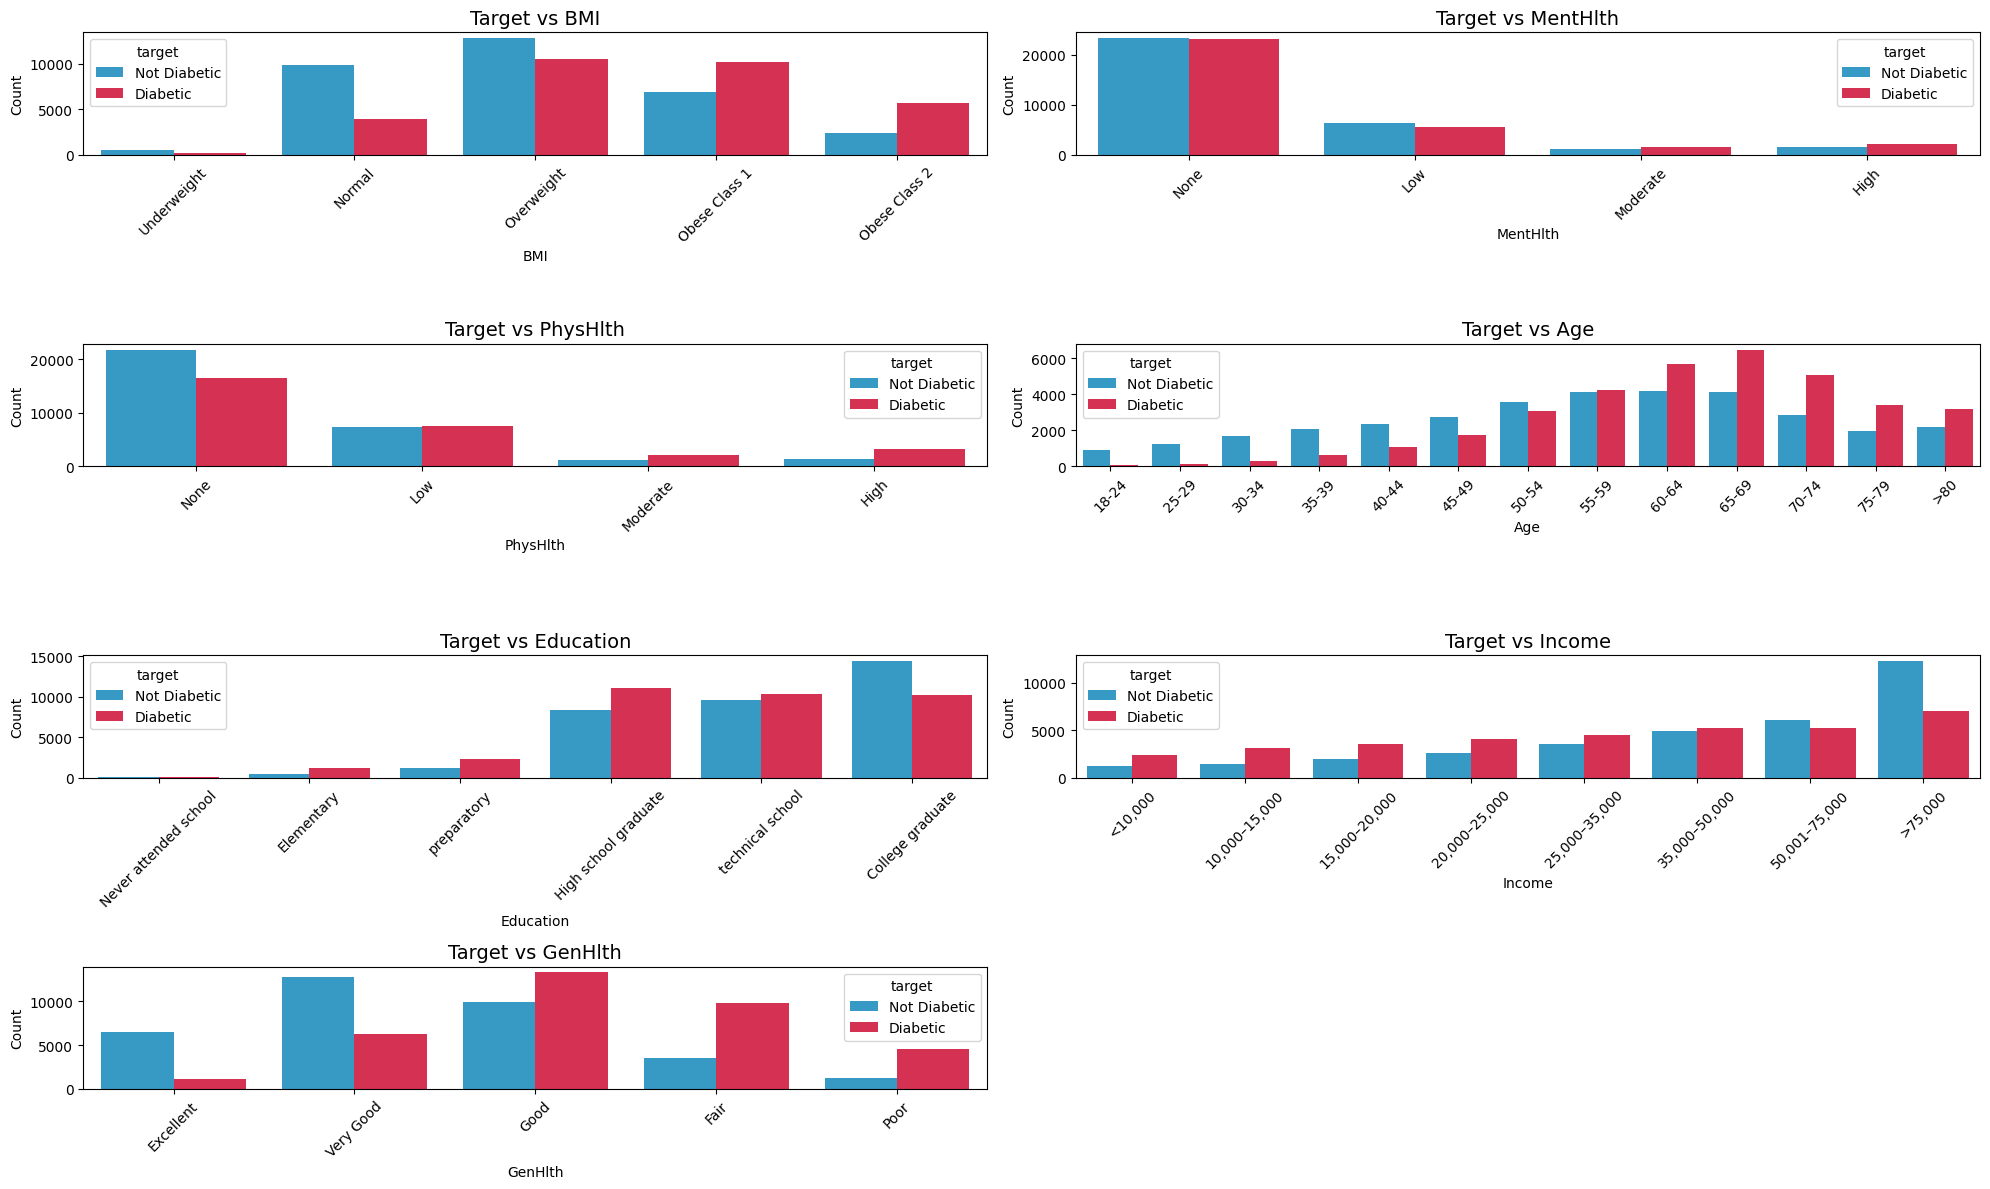

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define bin edges and labels
bmi_bins = [0, 18.5, 24.9, 29.9, 34.9, 39.9]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese Class 1', 'Obese Class 2']

mental_bins = [-1, 0, 7, 14, 29]
mental_labels = ['None', 'Low', 'Moderate', 'High']

phys_bins = [-1, 0, 7, 14, 29]
phys_labels = ['None', 'Low', 'Moderate', 'High']

age_labels = ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49',
              '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '>80']

education_labels = ['Never attended school', 'Elementary', 'preparatory',
                    'High school graduate', 'technical school', 'College graduate']

income_labels = ['<10,000', '10,000–15,000', '15,000–20,000', '20,000–25,000',
                 '25,000–35,000', '35,000–50,000', '50,001–75,000', '>75,000']

genhlth_labels = ['Excellent', 'Very Good', 'Good', 'Fair', 'Poor']

# Example list of columns to plot (must match with your dataset)
c_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income', 'GenHlth']

# Set up subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 12))
axes = axes.flatten()

for i, column in enumerate(c_cols):
    if column == 'BMI':
        x_vals = pd.cut(df['BMI'], bins=bmi_bins, labels=bmi_labels)
    elif column == 'MentHlth':
        x_vals = pd.cut(df['MentHlth'], bins=mental_bins, labels=mental_labels)
    elif column == 'PhysHlth':
        x_vals = pd.cut(df['PhysHlth'], bins=phys_bins, labels=phys_labels)
    elif column == 'Age':
        x_vals = df['Age'].map(dict(enumerate(age_labels, start=1)))
        x_vals = pd.Categorical(x_vals, categories=age_labels, ordered=True)
    elif column == 'Education':
        x_vals = df['Education'].map(dict(enumerate(education_labels, start=1)))
        x_vals = pd.Categorical(x_vals, categories=education_labels, ordered=True)
    elif column == 'Income':
        x_vals = df['Income'].map(dict(enumerate(income_labels, start=1)))
        x_vals = pd.Categorical(x_vals, categories=income_labels, ordered=True)
    elif column == 'GenHlth':
        x_vals = df['GenHlth'].map(dict(enumerate(genhlth_labels, start=1)))
        x_vals = pd.Categorical(x_vals, categories=genhlth_labels, ordered=True)
    
    # Combine into a temp DataFrame
    temp_df = pd.DataFrame({
        column: x_vals,
        'target': df['target'].map({0: 'Not Diabetic', 1: 'Diabetic'})
    })

    # Plot
    sns.countplot(data=temp_df, x=column, hue='target',
                  palette=['#1FA3DD', '#F11541'], ax=axes[i])

    axes[i].set_title(f"Target vs {column}", fontsize=14)
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots if any
if len(c_cols) < len(axes):
    for j in range(len(c_cols), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Its remarkable that:

* As BMI increases diabeic patients are more (important relation)
* In general people health is 3 or more(good or less) are dieabetic (important relation)
* As age increases, diabetic patients increases(important relation)
* Mental health and physical health injury days increase, people are likely to have diabetes (slightly)
* As the education decreases diabetic patients increases (which is a strange correlation but also may represent that less educated people arent aware of their health)
* As the Income decreases diabetic patients increases (which is a strange correlation but also may represent that people with less income ignore their health)

Recap for features having relation(indecators for) with target(diabetic or not):

* BMI (positive)
* general health (positive)
* Age (positive)
* Education (negative)
* Income (negative)
* BloodPressure (positive)
* Cholesterol (positive)
  

## Plotting Important Features with target

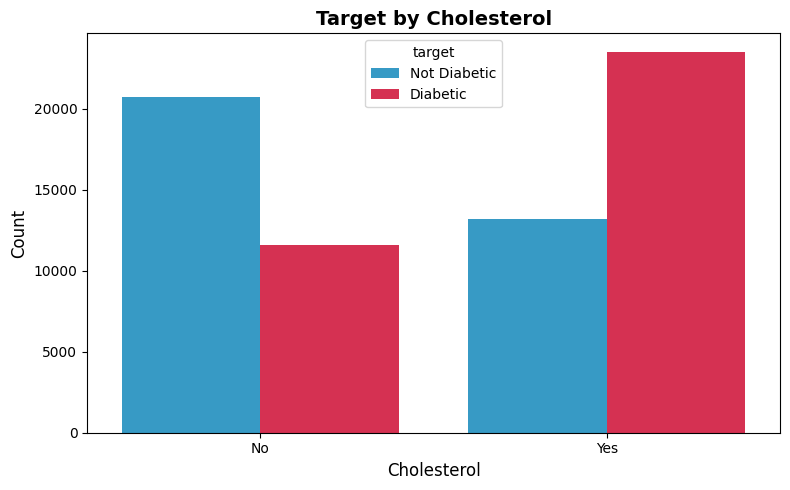

In [50]:
plt.figure(figsize=(8, 5))

sns.countplot(x='HighChol',  hue=df['target'].map({0: 'Not Diabetic', 1: 'Diabetic'}), data=df, palette=['#1FA3DD', '#F11541'])

plt.title("Target by Cholesterol", fontsize=14, fontweight='bold')
plt.xlabel("Cholesterol", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks([0, 1], ['No', 'Yes'])

plt.tight_layout()
plt.show()

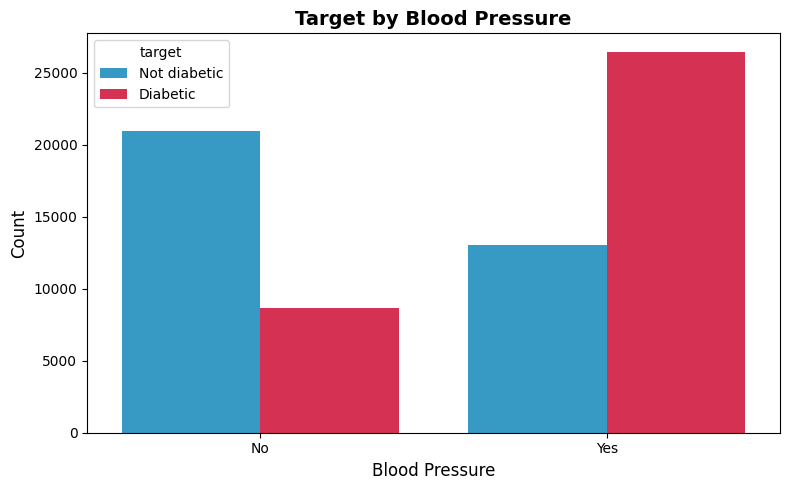

In [51]:
plt.figure(figsize=(8, 5))

sns.countplot(x='HighBP', hue=df['target'].map({0: 'Not diabetic', 1: 'Diabetic'}), data=df, palette=['#1FA3DD', '#F11541'], dodge=True)

plt.title("Target by Blood Pressure", fontsize=14, fontweight='bold')
plt.xlabel("Blood Pressure", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks([0, 1], ['No', 'Yes'])

# Show the plot
plt.tight_layout()
plt.show()

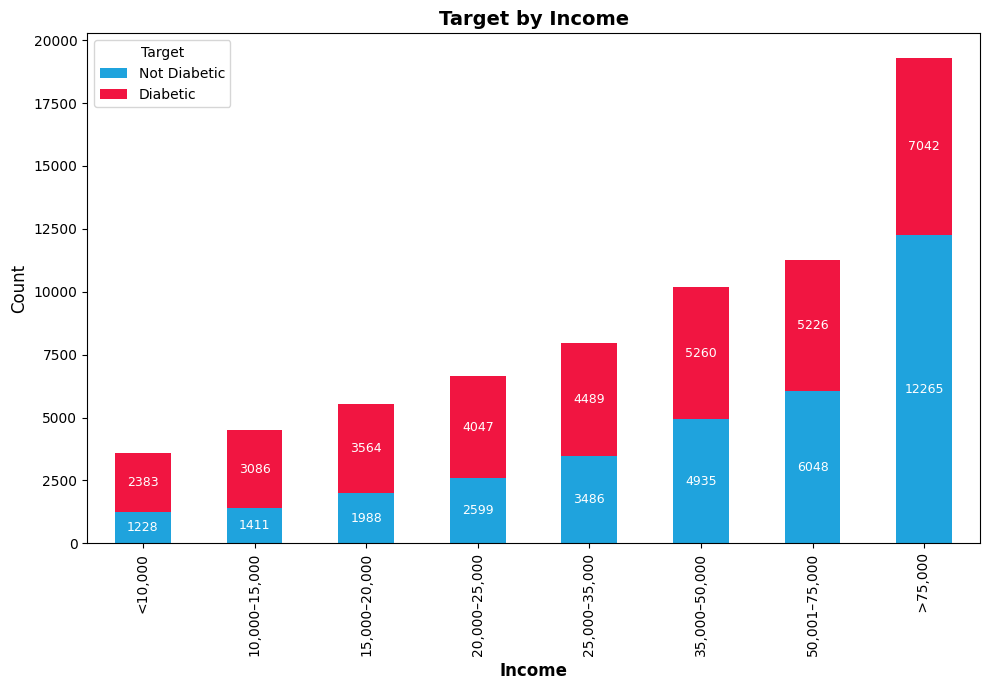

In [55]:
count_data = df.groupby(['Income', 'target']).size().unstack()
ax = count_data.plot( kind='bar',stacked=True,color=['#1FA3DD', '#F11541'],figsize=(10, 7))

plt.title("Target by Income", fontsize=14, fontweight='bold')
plt.xlabel("Income", fontsize=12,fontweight='bold')
plt.ylabel("Count", fontsize=12)
plt.legend(title='Target', labels=['Not Diabetic','Diabetic'], loc='upper left')
ax.set_xticklabels(['<10,000','10,000–15,000','15,000–20,000','20,000–25,000','25,000–35,000','35,000–50,000','50,001–75,000',' >75,000'])

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2, 
                int(height),
                ha='center',
                va='center',
                fontsize=9,
                color='white'  
            )
plt.tight_layout()
plt.show()

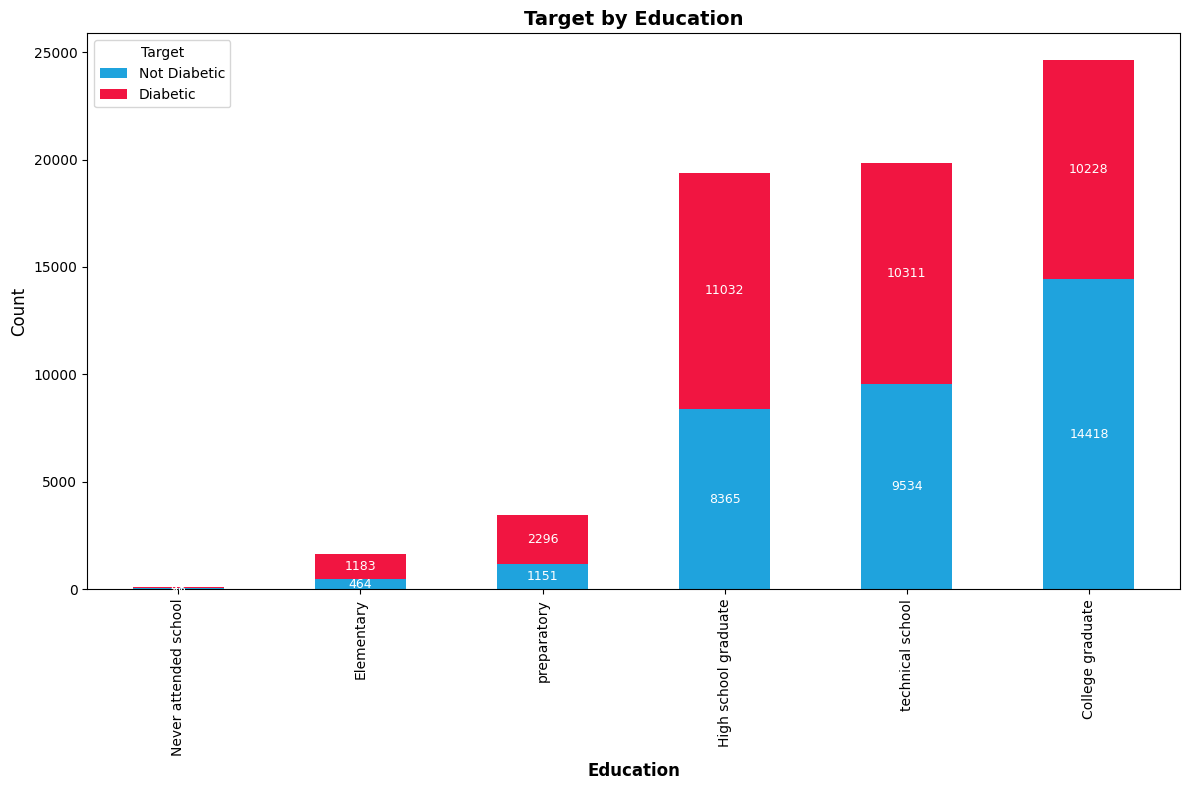

In [59]:
count_data = df.groupby(['Education', 'target']).size().unstack()

ax = count_data.plot(kind='bar', stacked=True,color=['#1FA3DD', '#F11541'],figsize=(12, 8))

plt.title("Target by Education", fontsize=14, fontweight='bold')
plt.xlabel("Education", fontsize=12,fontweight='bold')
plt.ylabel("Count", fontsize=12)
plt.legend(title='Target', labels=['Not Diabetic','Diabetic'], loc='upper left')
ax.set_xticklabels(['Never attended school','Elementary','preparatory','High school graduate','technical school','College graduate'])

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,  
                int(height),
                ha='center',
                va='center', 
                fontsize=9,
                color='white' 
            )
plt.tight_layout()
plt.show()


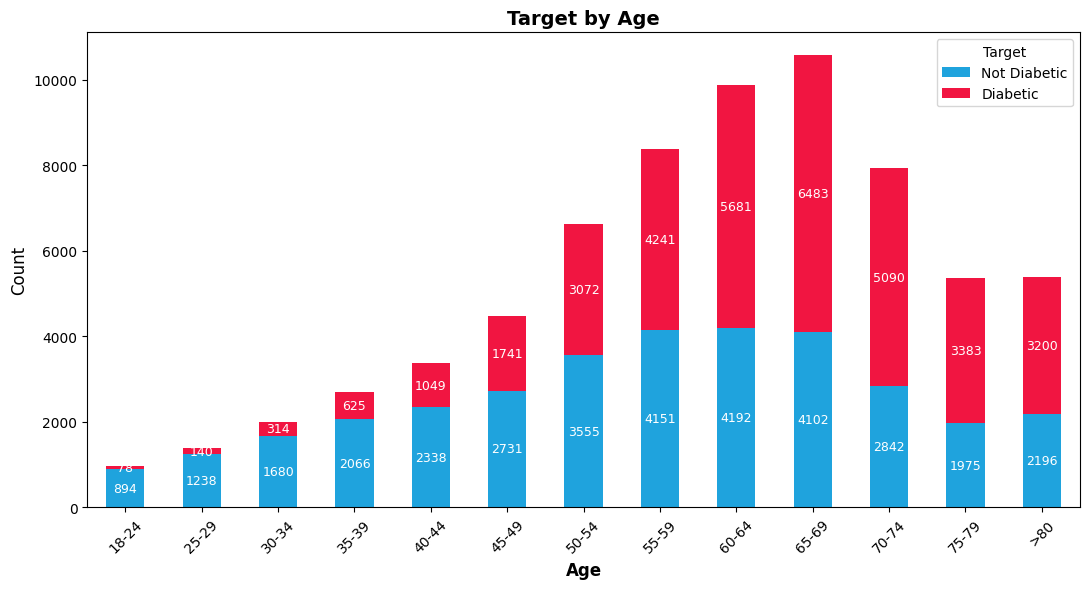

In [60]:
count_data = df.groupby(['Age', 'target']).size().unstack()


ax = count_data.plot(kind='bar',stacked=True,color=['#1FA3DD', '#F11541'],figsize=(11, 6))

plt.title("Target by Age", fontsize=14, fontweight='bold')
plt.xlabel("Age", fontsize=12, fontweight='bold')
plt.ylabel("Count", fontsize=12)
plt.legend(title='Target', labels=['Not Diabetic','Diabetic'], loc='upper right')
ax.set_xticklabels(['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', 
                    '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '>80'], rotation=45)
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,  
                int(height),
                ha='center',
                va='center', 
                fontsize=9,
                color='white' )

plt.tight_layout()
plt.show()

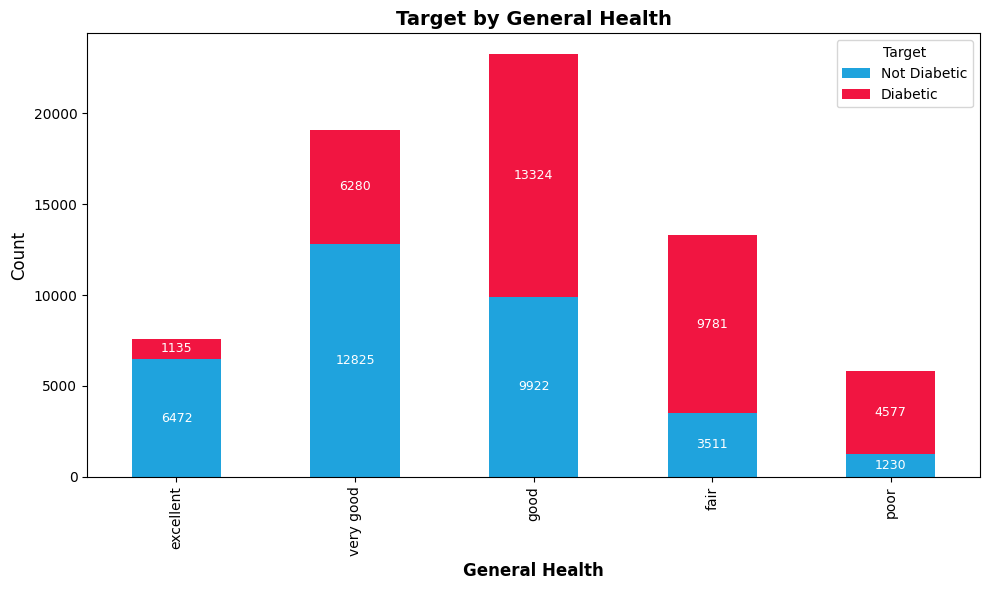

In [62]:
count_data = df.groupby(['GenHlth', 'target']).size().unstack()

ax = count_data.plot(kind='bar',stacked=True,color=['#1FA3DD', '#F11541'],figsize=(10, 6))

plt.title("Target by General Health", fontsize=14, fontweight='bold')
plt.xlabel("General Health", fontsize=12,fontweight='bold')
plt.ylabel("Count", fontsize=12)
ax.set_xticklabels(['excellent','very good', 'good','fair','poor'])

plt.legend(title='Target', labels=['Not Diabetic','Diabetic'], loc='upper right')

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2, 
                int(height),
                ha='center',
                va='center',  
                fontsize=9,
                color='white'  
            )
plt.tight_layout()
plt.show()

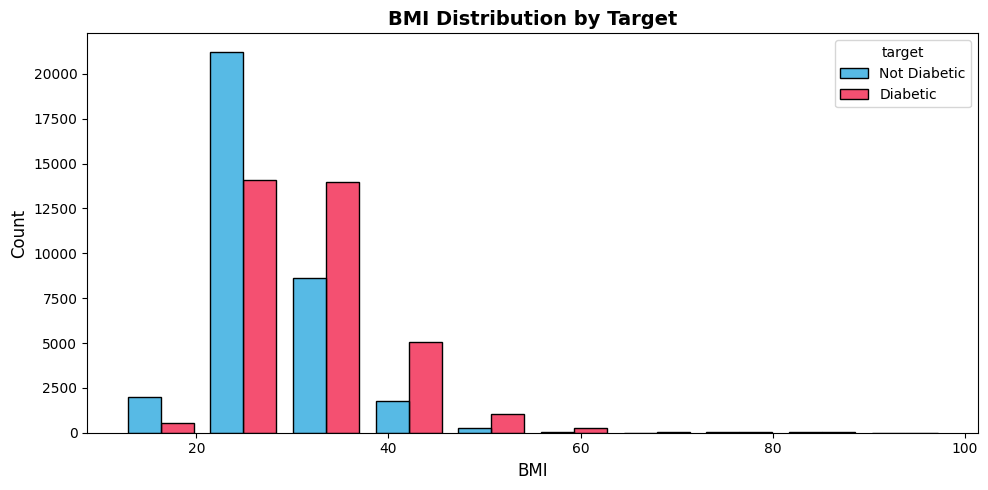

In [64]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='BMI',  hue=df['target'].map({0:'Not Diabetic',1:'Diabetic'}), multiple='dodge', bins=10, shrink=0.8, palette=['#1FA3DD', '#F11541'])

plt.title("BMI Distribution by Target", fontsize=14, fontweight='bold')
plt.xlabel("BMI", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()

plt.show()


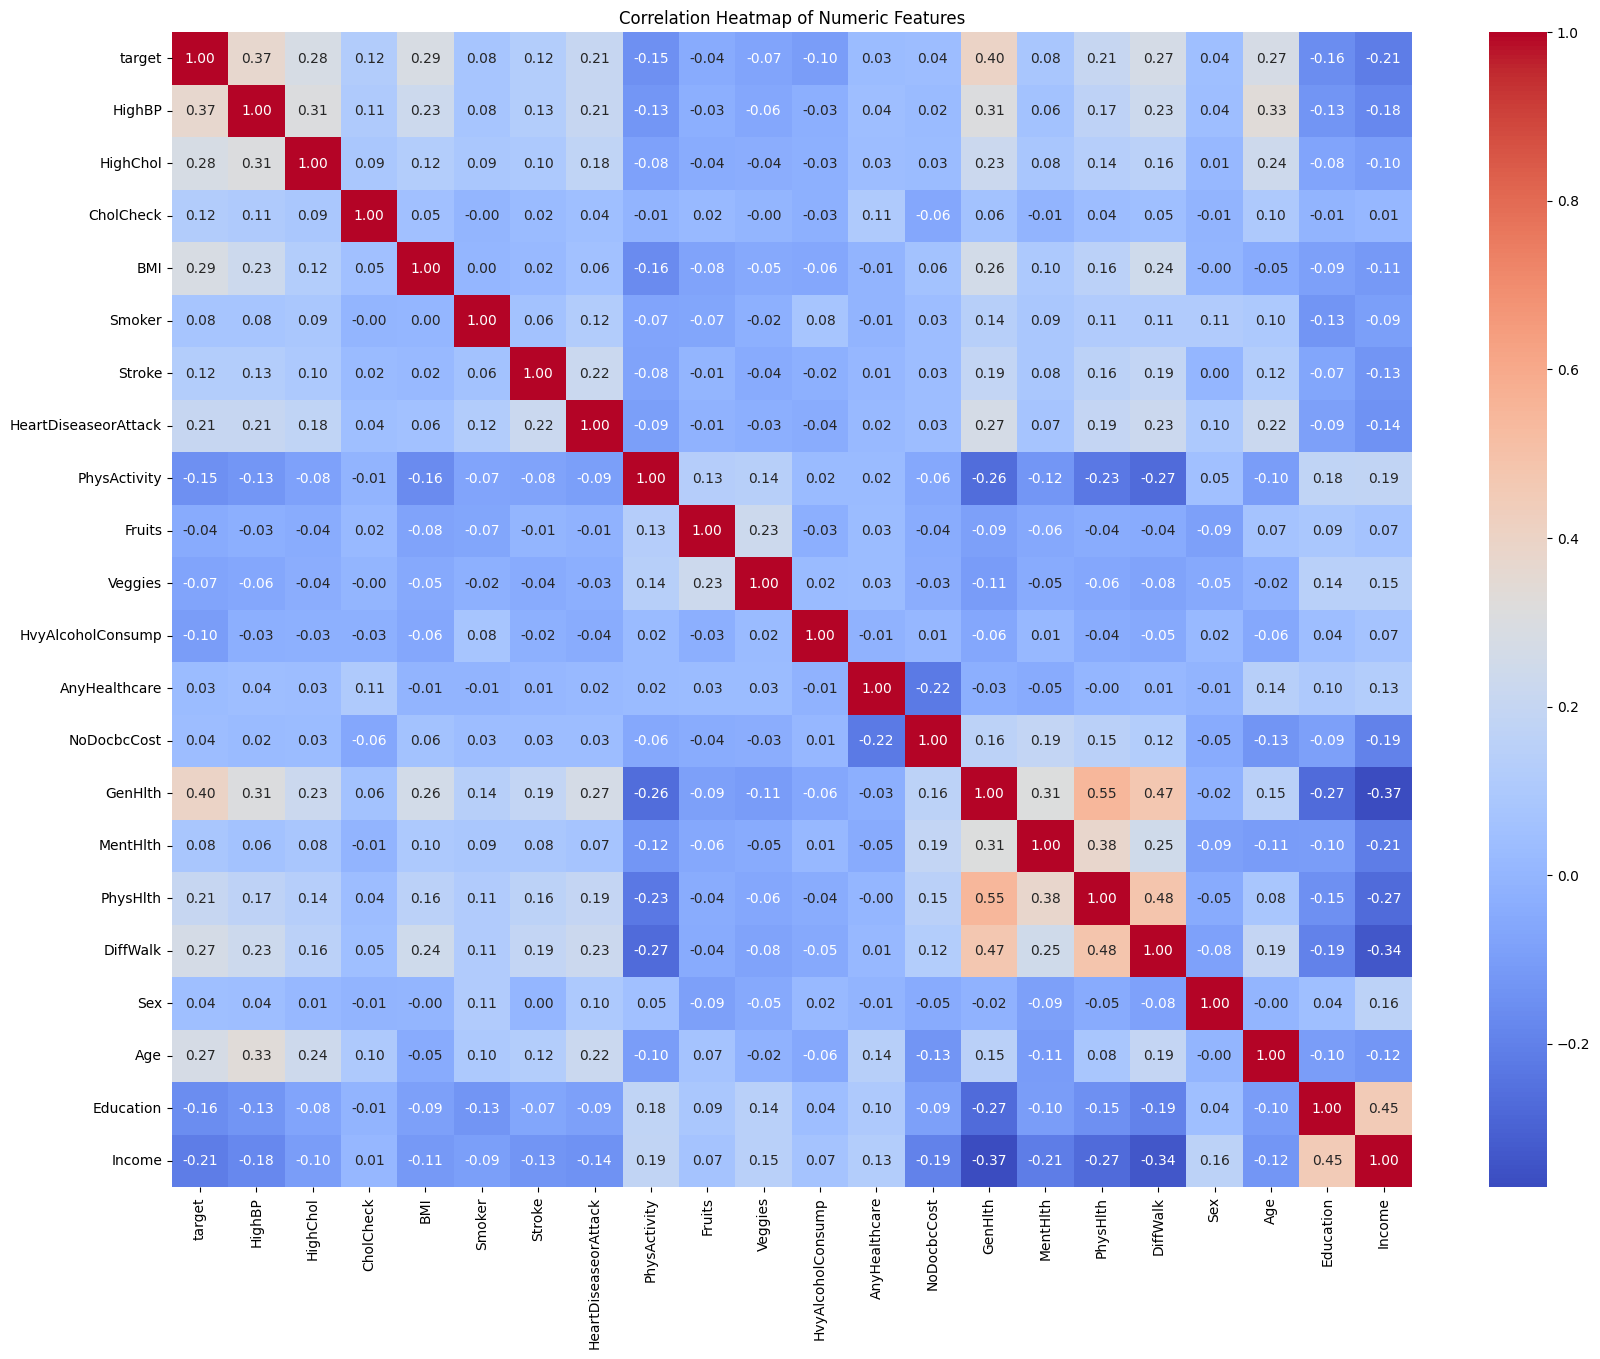

In [65]:
corr_matrix = df.corr()
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


# PCA

In [35]:
pca = PCA()
pca_components = pca.fit_transform(X_train)

### Applied PCA
We applied PCA to the scaled data. This transforms the data into new features (called principal components) that capture the most important patterns in the data.

In [38]:
explained_variance = pca.explained_variance_ratio_
print("\nExplained Variance Ratio for Each Principal Component:")
print(explained_variance)


Explained Variance Ratio for Each Principal Component:
[5.20392796e-01 2.09112401e-01 2.03103281e-01 3.42783017e-02
 1.84004385e-02 3.61386912e-03 2.93469626e-03 1.24433289e-03
 1.03451072e-03 1.00072652e-03 8.99487238e-04 7.47775085e-04
 6.78246589e-04 5.92300368e-04 5.26851968e-04 4.35339475e-04
 3.42100712e-04 2.23090451e-04 1.73657258e-04 1.65947197e-04
 9.98498108e-05]


In [40]:
cumulative_variance = explained_variance.cumsum()
for i, var in enumerate(explained_variance):
    print(f"Component {i+1}: {var:.4f} ({cumulative_variance[i]:.4f} cumulative)")

Component 1: 0.5204 (0.5204 cumulative)
Component 2: 0.2091 (0.7295 cumulative)
Component 3: 0.2031 (0.9326 cumulative)
Component 4: 0.0343 (0.9669 cumulative)
Component 5: 0.0184 (0.9853 cumulative)
Component 6: 0.0036 (0.9889 cumulative)
Component 7: 0.0029 (0.9918 cumulative)
Component 8: 0.0012 (0.9931 cumulative)
Component 9: 0.0010 (0.9941 cumulative)
Component 10: 0.0010 (0.9951 cumulative)
Component 11: 0.0009 (0.9960 cumulative)
Component 12: 0.0007 (0.9968 cumulative)
Component 13: 0.0007 (0.9974 cumulative)
Component 14: 0.0006 (0.9980 cumulative)
Component 15: 0.0005 (0.9986 cumulative)
Component 16: 0.0004 (0.9990 cumulative)
Component 17: 0.0003 (0.9993 cumulative)
Component 18: 0.0002 (0.9996 cumulative)
Component 19: 0.0002 (0.9997 cumulative)
Component 20: 0.0002 (0.9999 cumulative)
Component 21: 0.0001 (1.0000 cumulative)


#### We calculated how much of the total data variance is explained by each principal component. 
This tells us how useful each component is.
* Component 5: 43%
* Component 10: 66%
* Component 15: 84%

Cumulative variance (first 19 Component ) ≈ 95%

* The data is complex because we need 19 out of 21 components to cover 95% of the information.

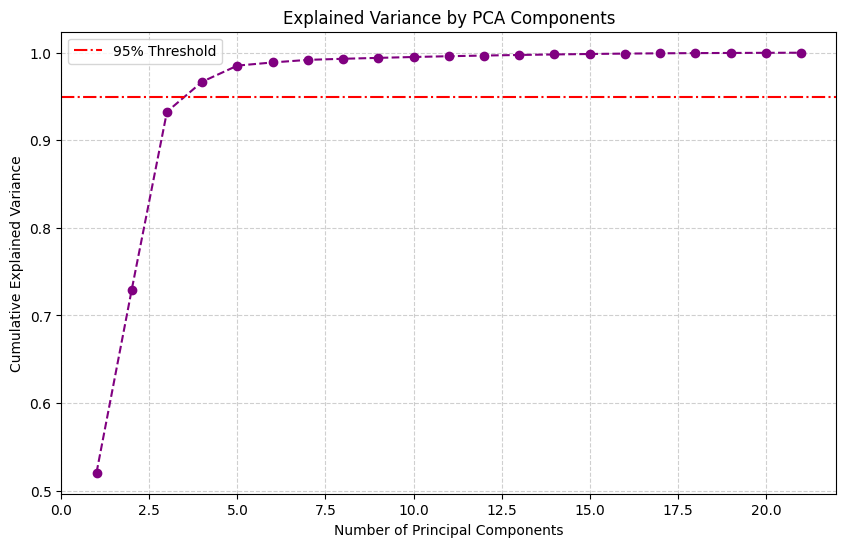

In [43]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o', linestyle='--', color='purple')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(y=0.95, color='red', linestyle='-.', label='95% Threshold')
plt.legend()
plt.show()

In [45]:
components_df = pd.DataFrame(pca.components_, columns=X_train.columns, index=[f'PC{i+1}' for i in range(pca.n_components_)])
print("\nPrincipal Components (PCs) Contributions to Original Features:")
print(components_df)


Principal Components (PCs) Contributions to Original Features:
        HighBP  HighChol  CholCheck       BMI    Smoker    Stroke  \
PC1   0.008050  0.006790   0.000426  0.171753  0.005570  0.003446   
PC2   0.012007  0.005162   0.001225  0.559575 -0.001471  0.000540   
PC3   0.008273  0.003967   0.000254  0.809334 -0.002146 -0.001428   
PC4  -0.062181 -0.044600  -0.005369 -0.012329 -0.019593 -0.011201   
PC5   0.006012 -0.004868  -0.003409 -0.032945  0.010271  0.006997   
PC6   0.069017  0.059800   0.005402 -0.020283  0.080745  0.012036   
PC7  -0.100679 -0.088640  -0.006162  0.020363 -0.005050 -0.025320   
PC8   0.167957  0.226262  -0.003092 -0.003602  0.466460  0.020102   
PC9  -0.320578 -0.477370  -0.017802  0.001266 -0.289876 -0.023033   
PC10 -0.390599 -0.625519  -0.020201  0.011985  0.449701 -0.015573   
PC11  0.086169 -0.088507   0.003287  0.000606 -0.673840 -0.005508   
PC12 -0.219152  0.142472   0.000735  0.007466  0.100165 -0.034829   
PC13 -0.792610  0.529864  -0.010254  0.

In [47]:
pca = PCA(n_components=0.99)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [49]:
n_components = pca.n_components_
print(f"\ncomponents: {n_components}")  


components: 7


In [51]:
pca_df = pd.DataFrame(data=X_train_pca, columns=[f'PC{i+1}' for i in range(n_components)])

In [53]:
pca_df['target'] = y_train.values

In [55]:
print(pca_df.head())

         PC1       PC2        PC3       PC4       PC5       PC6       PC7  \
0  -5.170726 -0.679689  -4.576048 -2.272545 -0.116831  1.486910 -0.497995   
1  18.378035  9.364477 -13.937592 -1.648192  2.628395  0.451258 -0.617112   
2  20.510325  0.580950  -8.410904  1.401381 -0.166252 -0.062216 -0.241292   
3  -7.849205 -1.658075  -3.444978 -2.998317 -1.682111 -0.308235 -0.864182   
4  -5.620114 -0.759298  -2.896446  2.401362  5.535617  1.846975  0.887563   

   target  
0     1.0  
1     1.0  
2     0.0  
3     1.0  
4     0.0  


# Principal Components (PCs) Contributions to Original Features
This table shows how each feature (like BMI or Age) helps create the first three principal components (PCs) after PCA. Each number (loading) shows how much a feature affects a component.
# PC1: Overall Physical Health
Key Features:
* HighBP (0.53): High blood pressure
* BMI (0.47): Body mass index
* HeartDiseaseorAttack (0.46): Heart disease history
* PhysHlth (0.35): Physical health
* DiffWalk (0.37): Trouble walking
* GenHlth (0.41): General health
  
PC1 focuses on physical health issues. High blood pressure, BMI, and heart disease matter most, showing this component tracks chronic health and physical condition.

# PC2: Age and Chronic Diseases
Key Features:
* Age (0.48): Age
* HighChol (0.28): High cholesterol
* CholCheck (0.24): Cholesterol check
  
PC2 is about age and long-term health problems like high cholesterol. It highlights health issues that come with getting older.

# PC3: Lifestyle and Diet Habits
Key Features:
* Fruits (0.56): Eating fruits
* Veggies (0.49): Eating vegetables
* MentHlth (0.22): Mental health
* PhysHlth (0.23): Physical health
* Sex (-0.42): Gender (negative impact)
  
PC3 focuses on diet and lifestyle. Fruits and veggies are big factors, and mental/physical health play a role. The negative weight for Sex suggests men and women might differ in these habits.

In [58]:
mean_values = pca_df.groupby('target')[[f'PC{i+1}' for i in range(n_components)]].mean()
print(mean_values)

             PC1       PC2       PC3       PC4       PC5       PC6       PC7
target                                                                      
0.0    -2.565882 -1.409223 -1.045129  0.873354 -0.150893 -0.144719  0.161934
1.0     2.490353  1.367741  1.014364 -0.847646  0.146451  0.140459 -0.157168


In [60]:
std_values = pca_df.groupby('target')[[f'PC{i+1}' for i in range(n_components)]].std()
print(std_values)

              PC1       PC2       PC3       PC4       PC5       PC6       PC7
target                                                                       
0.0      9.070184  6.333674  6.210349  3.072217  2.017326  0.895116  0.803504
1.0     12.338097  7.455418  7.481217  2.344510  2.158188  0.938823  0.838454


## General Observations:

* PC1 is the Key Separator:
The average (mean) for Diabetic people (0.872) is much higher than for Non-Diabetic people (-0.873), showing a clear difference between the two groups.
* Shows More Variation in Diabetic Group:
Diabetic people have a slightly higher spread (standard deviation: 1.779) compared to Non-Diabetic people (1.599), meaning their data varies a bit more.
* PC2 helps but Less Than PC1:
The averages for Diabetic (0.290) and Non-Diabetic (-0.290) people are similar in size but opposite in direction, indicating a moderate difference.
* Has More Variation in Non-Diabetic Group:
Non-Diabetic people have a slightly higher spread (standard deviation: 1.340) compared to Diabetic people (1.234), meaning their data is a bit more varied.
* PC3 Doesn’t Help Much:
The averages for Diabetic (-0.042) and Non-Diabetic (0.042) people are very close and almost equal, showing little difference between the groups.
* Has Slightly More Variation in Diabetic Group:
Diabetic people have a slightly higher spread (standard deviation: 1.186) compared to Non-Diabetic people (1.122), meaning their data varies a little more.

# SVM

In [58]:
def model_pipeline(preprocessor, pca_components=10,svm_kernel='rbf', svm_c=1.0, svm_gamma='scale', random_state=42):
    """Creates the full pipeline with preprocessing, PCA, and SVM.  Uses standard PCA."""
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('pca', PCA(n_components=pca_components, random_state=random_state)),  
        ('svm', SVC(kernel=svm_kernel, C=svm_c, gamma=svm_gamma, random_state=random_state))
    ])
    return pipeline

In [60]:
def tune_hyperparameters(pipeline, X_train, y_train, param_grid, cv=3, scoring='accuracy', verbose=1,n_jobs=-1):
    """Tunes hyperparameters using GridSearchCV."""

    grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring=scoring, verbose=verbose,n_jobs=n_jobs)
    grid_search.fit(X_train, y_train)
    print("Best Hyperparameters:", grid_search.best_params_)
    return grid_search.best_estimator_


In [62]:
def evaluate_model(model, X_test, y_test):
    """Evaluates the model and prints metrics."""

    y_pred = model.predict(X_test)
    print("Evaluation Metrics:")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
    return y_pred

In [64]:
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['rbf', 'linear'],
    'svm__gamma': ['scale', 0.1]
}
full_pipeline = model_pipeline(preprocessor)

In [ ]:
full_pipeline.fit(X_train, y_train)

In [ ]:
best_model = tune_hyperparameters(full_pipeline, X_train, y_train, param_grid)

In [ ]:
# Predictions on TRAINING data (to check for overfitting)
print("=== Training Performance ===")
evaluate_model(best_model, X_train, y_train)

In [ ]:
# Predictions on TEST data (real evaluation)
print("\n=== Test Performance ===")
evaluate_model(best_model, X_test, y_test)

In [ ]:
# --- Confusion Matrix Visualization ---
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-Diabetic', 'Diabetic'],
                yticklabels=['Non-Diabetic', 'Diabetic'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
# Actually generate the plot
plot_confusion_matrix(y_test, evaluate_model(best_model, X_test, y_test)) 

# Report

In [66]:
full_pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object'))])),
                ('pca', PCA(n_components=10, random_state=42)),
                ('svm', SVC(random_state=42))])

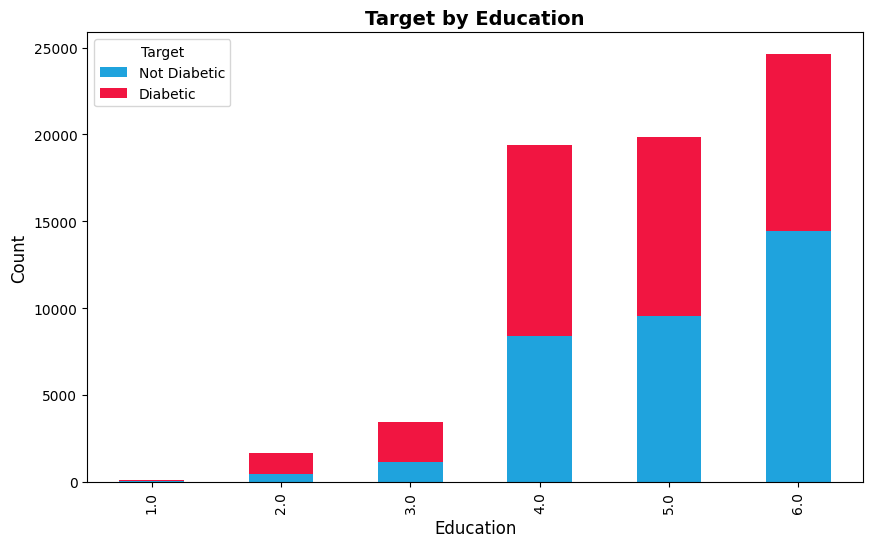

In [78]:
class PlotViewer(tk.Tk):
    def __init__(self, df):
        super().__init__()
        self.df = df
        self.title("Important Features Plotting")
        self.geometry("900x600")

        self.plot_functions_map = {
            "High Cholesterol vs. Target": self.plot_highchol,
            "High Blood Pressure vs. Target": self.plot_highbp,
            "Income vs. Target": self.plot_income,
            "Education vs. Target": self.plot_education,
            "Age vs. Target": self.plot_age,
            "General Health vs. Target": self.plot_genhlth,
            "BMI vs. Target": self.plot_bmi
        }
        self.plot_names = list(self.plot_functions_map.keys())

        self.notebook = ttk.Notebook(self)
        self.notebook.pack(expand=True, fill='both')

        self.create_home_page()
        self.plot_frames = {} 

        self.notebook.bind("<<NotebookTabChanged>>", self.on_tab_change)

    def create_home_page(self):
        self.home_frame = ttk.Frame(self.notebook)
        self.notebook.add(self.home_frame, text="Home")

        title_label = ttk.Label(self.home_frame, text="Select a Plot to Visualize", font=("Arial", 16))
        title_label.pack(pady=20)

        self.selected_plot_name = tk.StringVar()
        self.plot_choice = ttk.Combobox(self.home_frame, textvariable=self.selected_plot_name, values=self.plot_names, width=40, state="readonly")
        self.plot_choice.pack(pady=10)
        self.plot_choice.set("Select a Plot") 

        show_button = ttk.Button(self.home_frame, text="Show Plot", command=self.show_selected_plot)
        show_button.pack(pady=10)

    def show_selected_plot(self):
        selected_name = self.selected_plot_name.get()
        if selected_name in self.plot_functions_map:
            if selected_name not in self.plot_frames:
                plot_frame = ttk.Frame(self.notebook)
                self.plot_frames[selected_name] = plot_frame
                self.notebook.add(plot_frame, text=selected_name)
                self.plot_functions_map[selected_name](plot_frame)
            self.notebook.select(self.plot_frames[selected_name])

    def on_tab_change(self, event):
        selected_tab = self.notebook.select()
        home_tab_id = self.notebook.tabs()[0] 

        if selected_tab == home_tab_id:
            tabs_to_remove = list(self.plot_frames.keys())
            for name in tabs_to_remove:
                if name in self.plot_frames:
                    self.notebook.forget(self.plot_frames[name])
                    del self.plot_frames[name]

    def plot_highchol(self, parent):
        fig = plt.figure(figsize=(8, 5))
        sns.countplot(x='HighChol', hue='target', data=self.df, palette=['#1FA3DD', '#F11541'], dodge=True)
        plt.title("Target by High Cholesterol", fontsize=14, fontweight='bold')
        plt.xlabel("High Cholesterol", fontsize=12)
        plt.ylabel("Count", fontsize=12)
        plt.xticks([0, 1], ['No', 'Yes'])
        plt.legend(title='Target', labels=['Not Diabetic','Diabetic'], loc='upper center')
        plt.tight_layout()
        self.embed_plot(fig, parent)

    def plot_highbp(self, parent):
        fig = plt.figure(figsize=(8, 5))
        sns.countplot(x='HighBP', hue='target', data=self.df, palette=['#1FA3DD', '#F11541'], dodge=True)
        plt.title("Target by High Blood Pressure", fontsize=14, fontweight='bold')
        plt.xlabel("High Blood Pressure", fontsize=12)
        plt.ylabel("Count", fontsize=12)
        plt.xticks([0, 1], ['No', 'Yes'])
        plt.legend(title='Target', labels=['Not Diabetic','Diabetic'], loc='upper center')
        plt.tight_layout()
        self.embed_plot(fig, parent)

    def plot_income(self, parent):
        count_data = self.df.groupby(['Income', 'target']).size().unstack()
        fig = plt.figure(figsize=(8, 5))
        count_data.plot(kind='bar', stacked=True, color=['#1FA3DD', '#F11541'], ax=plt.gca())
        plt.title("Target by Income", fontsize=14, fontweight='bold')
        plt.xlabel("Income", fontsize=12)
        plt.ylabel("Count", fontsize=12)
        plt.legend(title='Target',labels=['Not Diabetic','Diabetic'], loc='upper left')
        plt.tight_layout()
        self.embed_plot(fig, parent)

    def plot_education(self, parent):
        count_data = self.df.groupby(['Education', 'target']).size().unstack()
        fig = plt.figure(figsize=(8, 5))
        count_data.plot(kind='bar', stacked=True, color=['#1FA3DD', '#F11541'], ax=plt.gca())
        plt.title("Target by Education", fontsize=14, fontweight='bold')
        plt.xlabel("Education", fontsize=12)
        plt.ylabel("Count", fontsize=12)
        plt.legend(title='Target', labels=['Not Diabetic','Diabetic'], loc='upper left')
        plt.tight_layout()
        self.embed_plot(fig, parent)

    def plot_age(self, parent):
        count_data = self.df.groupby(['Age', 'target']).size().unstack()
        fig = plt.figure(figsize=(8, 5))
        count_data.plot(kind='bar', stacked=True, color=['#1FA3DD', '#F11541'], ax=plt.gca())
        plt.title("Target by Age", fontsize=14, fontweight='bold')
        plt.xlabel("Age", fontsize=12)
        plt.ylabel("Count", fontsize=12)
        plt.legend(title='Target', labels=['Not Diabetic','Diabetic'], loc='upper right')
        plt.tight_layout()
        self.embed_plot(fig, parent)

    def plot_genhlth(self, parent):
        count_data = self.df.groupby(['GenHlth', 'target']).size().unstack()
        fig = plt.figure(figsize=(8, 5))
        count_data.plot(kind='bar', stacked=True, color=['#1FA3DD', '#F11541'], ax=plt.gca())
        plt.title("Target by General Health", fontsize=14, fontweight='bold')
        plt.xlabel("General Health", fontsize=12)
        plt.ylabel("Count", fontsize=12)
        plt.legend(title='Target',labels=['Not Diabetic','Diabetic'], loc='upper right')
        plt.tight_layout()
        self.embed_plot(fig, parent)

    def plot_bmi(self, parent):
        fig = plt.figure(figsize=(10, 7))
        sns.histplot(data=df, x='BMI',  hue=df['target'].map({0:'Not Diabetic',1:'Diabetic'}), multiple='dodge', bins=10, shrink=0.8, palette=['#1FA3DD', '#F11541'])
        plt.title("BMI Distribution by Target", fontsize=14, fontweight='bold')
        plt.xlabel("BMI", fontsize=12)
        plt.ylabel("Count", fontsize=12)
        plt.tight_layout()
        self.embed_plot(fig, parent)

    def embed_plot(self, fig, parent):
        canvas = FigureCanvasTkAgg(fig, master=parent)
        canvas_widget = canvas.get_tk_widget()
        canvas_widget.pack(fill=tk.BOTH, expand=True)
        canvas.draw()

if __name__ == "__main__":
    app = PlotViewer(df)
    app.mainloop()

In [93]:
profile = ProfileReport(pd.read_csv(r"C:\Users\dell\Downloads\diabetes_binary_5050split_health_indicators_BRFSS2015.csv"), title="EDA Report", explorative=True)
profile.to_file("eda_report.html")  

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 22/22 [00:02<00:00,  8.06it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]